In [1]:
%cd /scratch/users/baranh/deep_0/SpherePackings
import os
import numpy as np
import torch
import time
import math
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.notebook import tqdm
import configparser
from diffuse_boost.spheres_in_cube import data_load_save
from datetime import datetime
from diffuse_boost.spheres_in_cube.plot_data_points import plot_3d
import diffuse_boost.spheres_in_Rd.data_evaluation as data_evaluation
from diffuse_boost.spheres_in_Rd.data_evaluation import plot_evaluations

from torchdiffeq import odeint
import schedulefree
from x_transformers import ContinuousTransformerWrapper, Encoder

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath, CondOTProbPath
from flow_matching.utils import ModelWrapper
from flow_matching.solver import ODESolver
from torch.distributions import Independent, Normal

from diffuse_boost import cfg

/scratch/users/baranh/deep_0/SpherePackings
file:  /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/__init__.py
here
Loaded configuration file /scratch/users/baranh/deep_0/SpherePackings/config.cfg!


In [2]:
# Continuous flow matching path with CondOT (linear) scheduler
FM_PATH = AffineProbPath(scheduler=CondOTScheduler())

# Model 

In [3]:
class FlowSetTransformer(nn.Module):
    class TimeEmbedFourier(nn.Module):
        def __init__(
            self,
            out_dim: int,
            fourier_dim: int,
            hidden: int,
            sigma: float = 1.0,
            include_poly: bool = True,
        ):
            super().__init__()
            fourier_dim = max(16, fourier_dim)
            # fixed (non-trainable) Fourier frequencies
            self.register_buffer("freqs", torch.randn(fourier_dim) * sigma, persistent=False)
            self.include_poly = include_poly
            in_dim = 2 * fourier_dim
            if include_poly:
                in_dim += 4  # [t, t^2, t^3, log(1+t)]
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.SiLU(),
                nn.Linear(hidden, out_dim),
            )

        def forward(self, t: torch.Tensor) -> torch.Tensor:
            # t: (B,) or (B,1) -> (B,)
            if t.ndim == 2:
                assert t.shape[1] == 1, f"t must be (B,) or (B,1); got {t.shape}"
                t = t[:, 0]
            t = t.contiguous()
            # Fourier features
            angles = (t[:, None] * self.freqs[None, :]) * (2.0 * math.pi)
            sin_feat = torch.sin(angles)
            cos_feat = torch.cos(angles)
            feats = [sin_feat, cos_feat]
            if self.include_poly:
                t1 = t
                t2 = t1 * t1
                t3 = t2 * t1
                tlog = torch.log1p(t1.clamp_min(0))
                feats += [t1[:, None], t2[:, None], t3[:, None], tlog[:, None]]

            h = torch.cat(feats, dim=-1)
            return self.net(h)

    def __init__(self, d: int = 3, **st_kwargs):
        super().__init__()
        self.d = d
        model_dim = int(st_kwargs.get("dim_hidden", 512))
        heads = int(st_kwargs.get("num_heads", 8))
        depth = int(st_kwargs.get("depth", 2))
        ff_mult = float(st_kwargs.get("ff_mult", 4.0))
        attn_do = float(st_kwargs.get("attn_dropout", 0.1))
        ff_do = float(st_kwargs.get("ff_dropout", 0.1))
        dim_time = int(st_kwargs.get("dim_time", max(64, 4 * d)))
        time_F = int(st_kwargs.get("time_fourier_dim", max(16, dim_time // 2)))
        time_hid = int(st_kwargs.get("time_hidden", 2 * dim_time))
        sigma = float(st_kwargs.get("time_fourier_sigma", 1.0))

        # conditioning setup
        cond_dim_in  = int(st_kwargs.get("cond_dim_in", 4))   # keep default 4: [r/L, N/scale_N, p_face, minsep/L]
        cond_hidden  = int(st_kwargs.get("cond_hidden", max(64, dim_time)))
        self.uses_cond = cond_dim_in > 0

        # Time embedding (B,) / (B,1) -> (B, dim_time)
        self.time_emb = self.TimeEmbedFourier(
            out_dim=dim_time, fourier_dim=time_F, hidden=time_hid,
            sigma=sigma, include_poly=True
        )

        if self.uses_cond:
            self.cond_mlp = nn.Sequential(
                nn.Linear(cond_dim_in, cond_hidden),
                nn.SiLU(),
                nn.Linear(cond_hidden, cond_hidden)
            )
            dim_cond = cond_hidden
        else:
            self.cond_mlp = None
            dim_cond = 0

        # per-point coords + time + (optional) cond
        self.token_in = nn.Linear(d + dim_time + dim_cond, model_dim)

        # FiLM generator takes [time ⊕ cond] jointly
        self.film_in_dim = dim_time + dim_cond
        self.timecond_to_film = nn.Sequential(
            nn.SiLU(),
            nn.Linear(self.film_in_dim, 2 * model_dim)
        )

        self.encoder = Encoder(
            dim = model_dim,
            depth=depth,
            heads=heads,
            layer_dropout=0.1,
            attn_dropout=attn_do,
            ff_dropout=ff_do,
            use_rmsnorm=True,
            ff_glu=True,
            ff_no_bias=True,
            attn_flash=True
        )

        self.token_out = nn.Linear(model_dim, d)
        # Zero-init output to start near 0 velocity (stabilizes FM training)
        nn.init.zeros_(self.token_out.weight)
        nn.init.zeros_(self.token_out.bias)

    def forward(
        self,
        t: torch.Tensor,
        x: torch.Tensor,
        cond: torch.Tensor = None,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        t    : (B,) or (B,1)
        x    : (B, d, Nmax)
        cond : (B, C) or None     with C=4 by default: [r/L, N/scale_N, p_face, minsep/L]
        mask : (B, Nmax) bool or 0/1; True = attend, False = ignore (padded)
        ->    (B, d, Nmax)
        """
        B, d, N = x.shape
        assert d == self.d, f"Expected d={self.d}, got {d}"
        device = x.device
        dtype = x.dtype

        # --- time ---
        t = t.to(device=device, dtype=dtype)
        if t.ndim == 2:
            assert t.shape[1] == 1, f"t must be (B,) or (B,1); got {t.shape}"
            t_1d = t[:, 0]
        else:
            t_1d = t
        t_embed = self.time_emb(t_1d)  # (B, dim_time)

        # --- cond (classifier-free guidance: None -> zeros) ---
        if self.uses_cond:
            if cond is None:
                cond = torch.zeros(B, self.cond_mlp[0].in_features, device=device, dtype=dtype)
            else:
                cond = cond.to(device=device, dtype=dtype)
            c_embed = self.cond_mlp(cond)        # (B, dim_cond)
        else:
            c_embed = None

        # --- tokens (points) ---
        tokens = x.permute(0, 2, 1).contiguous()            # (B, N, d)
        if c_embed is not None:
            tc = torch.cat([t_embed, c_embed], dim=-1)      # (B, dim_time+dim_cond)
            tc_rep = tc[:, None, :].expand(B, N, -1)        # (B, N, ...)
            h = torch.cat([tokens, tc_rep], dim=-1)         # (B, N, d + dim_time + dim_cond)
            film_in = tc                                     # (B, dim_time+dim_cond)
        else:
            t_rep = t_embed[:, None, :].expand(B, N, -1)    # (B, N, dim_time)
            h = torch.cat([tokens, t_rep], dim=-1)          # (B, N, d + dim_time)
            film_in = t_embed                                # (B, dim_time)

        h = self.token_in(h)                                 # (B, N, model_dim)

        # --- FiLM modulation from joint [time ⊕ cond] ---
        gamma_beta = self.timecond_to_film(film_in)          # (B, 2*model_dim)
        gamma, beta = gamma_beta.chunk(2, dim=-1)            # each (B, model_dim)
        gamma = gamma[:, None, :]
        beta  = beta[:, None, :]
        h = h * (1 + gamma) + beta

        # --- mask handling ---
        if mask is not None:
            # ensure boolean on correct device
            mask = mask.to(device=device)
            if mask.dtype != torch.bool:
                mask = mask != 0
            # (B, N, 1) multiplicative mask helps stabilize pre-encoder stats
            h = h * mask[:, :, None].to(h.dtype)

        # --- encoder (expects mask with True=attend) ---
        h = self.encoder(h, mask=mask)                       # (B, N, model_dim)

        out = self.token_out(h).permute(0, 2, 1).contiguous()  # (B, d, N)

        # Zero out padded tokens in the output as well (nice-to-have, harmless if loss already masks)
        if mask is not None:
            out = out * mask[:, None, :].to(out.dtype)

        return out

In [4]:
#FlowSetTransformer()

# Training

In [5]:
_TRI_CACHE = {}
def distance_penalty(output, radius, margin=0.02, beta=10.0, p=2, q=0.2, eps=1e-12, mask: torch.Tensor = None):
    """
    output : (B,d,N)
    radius : float or (B,) per-sample radius
    margin : float or (B,) per-sample margin
    mask   : optional (B,N), True=attend
    """
    B, d, N = output.shape
    coords = output.permute(0, 2, 1).contiguous()             # (B,N,d)
    dmat = torch.cdist(coords, coords) + eps                  # (B,N,N)

    r = torch.as_tensor(radius, device=output.device, dtype=output.dtype)
    m = torch.as_tensor(margin, device=output.device, dtype=output.dtype)
    if r.ndim == 1: r = r.view(B, 1, 1)
    else:           r = r.reshape(B, 1, 1)
    if m.ndim == 1: m = m.view(B, 1, 1)
    else:           m = m.reshape(B, 1, 1)

    gap = (2 * r + m) - dmat                                  # (B,N,N)
    #v = F.softplus(beta * gap) / beta                         # (B,N,N)
    v = F.softplus(beta * gap.clamp_min(0.0)) / beta

    # mask out padded tokens
    if mask is not None:
        pairmask = (mask[:, :, None] & mask[:, None, :]).to(v.dtype)  # (B,N,N)
        v = v * pairmask

    key = (output.device, N)
    tri = _TRI_CACHE.get(key)
    if tri is None:
        tri = torch.triu_indices(N, N, offset=1, device=output.device)
        _TRI_CACHE[key] = tri
    v = v[:, tri[0], tri[1]]                                   # (B, pairs)

    if p != 1:
        v = v.pow(p)

    Pairs = max(1, v.size(1))
    #k = max(1, int(q * Pairs))
    k = max(2048, int(0.15 * Pairs))
    topk, _ = torch.topk(v, k=k, dim=1, largest=True, sorted=False)
    return topk.mean()


def _box_clamp(x, r, L):
    """
    Clamp per-sample: r can be scalar or (B,) or (B,1,1).
    x: (B,d,N)
    """
    r = torch.as_tensor(r, device=x.device, dtype=x.dtype)
    L = torch.as_tensor(L, device=x.device, dtype=x.dtype)
    if r.ndim == 0:
        lo = r
        hi = L - r
    else:
        lo = r.view(-1, 1, 1)
        hi = L.view(-1, 1, 1) - lo
    return x.clamp(lo, hi)

def sample_t(B, device, small_t_weight=0.5, gamma=2.0):
    s = torch.rand(B, device=device)
    t_small = s**gamma
    use_small = (torch.rand(B, device=device) < small_t_weight).float()
    return use_small * t_small + (1 - use_small) * s

def save_with_plot(model, optimizer, history, epoch, params, sec):
    save_dir = sec
    os.makedirs(save_dir, exist_ok=True)
    loss = history[-1,2]
    ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    name = f"flow_model_loss={loss:.4f}_{ts}.pth"
    path = os.path.join(save_dir, name)
    data_load_save.save_model(path, model, optimizer, epoch, params)

    plt.figure(figsize=(12,6))
    plt.plot(history[:,0], label="Flow MSE Loss")
    plt.plot(history[:,1], label="Distance Penalty")
    plt.plot(history[:,2], label="Total Loss")
    plt.yscale('log')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.grid()
    plt.savefig(os.path.join(save_dir, f"flow_loss_{ts}.png"))


def _sample_x1_box_faces_per_batch(
    x0, r, L, p_face_batch=None, jitter=5e-3,
    inward_eps=1e-4, stratified=False, exact_count=False
):
    """
    x0: (B,d,N) (only for shape/device)
    r : float or (B,) per-sample radius
    """
    B, d, N = x0.shape
    device, dtype = x0.device, x0.dtype
    r = torch.as_tensor(r, device=device, dtype=dtype)            # () or (B,)
    L = torch.as_tensor(L, device=device, dtype=dtype)

    # base interior samples
    if not stratified:
        u = torch.rand(B, d, N, device=device, dtype=dtype) * (L - 2*r.view(-1,1,1) if r.ndim>0 else (L-2*r)) + (r.view(-1,1,1) if r.ndim>0 else r)
    else:
        u = torch.empty(B, d, N, device=device, dtype=dtype)
        for ax in range(d):
            bins = (torch.arange(N, device=device, dtype=dtype)[None, None, :]
                    + torch.rand(B, 1, N, device=device, dtype=dtype)) / N
            vals = (r.view(-1,1,1) if r.ndim>0 else r) + (L - 2*(r.view(-1,1,1) if r.ndim>0 else r)) * bins
            perm = torch.argsort(torch.rand(B, 1, N, device=device), dim=-1)
            u[:, ax:ax+1, :] = vals.gather(2, perm)

    noise = jitter * torch.randn_like(u)

    if p_face_batch is not None:
        p = p_face_batch.to(device=device, dtype=dtype).clamp(0, 1)  # (B,)
        if exact_count:
            K = torch.distributions.Binomial(total_count=N, probs=p).sample().to(torch.long)
            keys = torch.rand(B, N, device=device)
            order = torch.argsort(keys, dim=1)
            mask = torch.zeros(B, N, device=device, dtype=torch.bool)
            for b in range(B):
                k = int(K[b].item())
                if k > 0:
                    mask[b, order[b, :k]] = True
        else:
            mask = (torch.rand(B, N, device=device) < p[:, None])   # (B,N)

        axis = torch.randint(0, d, (B, N), device=device)
        side = torch.randint(0, 2, (B, N), device=device)

        low_vals  = (r[:, None] + inward_eps) if r.ndim > 0 else (r + inward_eps)
        high_vals = (L - (r[:, None] + inward_eps)) if r.ndim > 0 else (L - (r + inward_eps))
        low_vals  = low_vals.expand(B, N)
        high_vals = high_vals.expand(B, N)
        face_pos  = torch.where(side == 0, low_vals, high_vals)     # (B,N)
        axis_oh = torch.zeros(B, d, N, device=device, dtype=dtype)
        axis_oh.scatter_(1, axis.unsqueeze(1), 1.0)
        noise = noise * (1.0 - axis_oh * mask[:, None, :].to(dtype))

        # add jitter & clamp
        u = _box_clamp(u + noise, r, L)

        # overwrite the axis coord at face tokens
        ar = torch.arange(B, device=device)[:, None].expand(B, N)
        nr = torch.arange(N, device=device)[None, :].expand(B, N)
        u[ar, axis, nr] = torch.where(mask, face_pos, u[ar, axis, nr])
    else:
        u = _box_clamp(u + noise, r, L)

    return u

def train_flow_model(
    model, optimizer, loader, num_epochs,
    sphere_radius, mse_strength, dist_strength,
    clip_min, clip_max, device, params, save_path
):
    model.train().to(device)
    optimizer.train()
    history, best = [], 1e9

    L = float(clip_max)  # box size upper bound, lower bound ~0
    for epoch in tqdm(range(num_epochs), desc="Training", dynamic_ncols=True):
        ep_losses=[]
        ratio = 0.5 * (1 - np.cos(np.pi * min(1.0, epoch / (0.5 * num_epochs))))
        for x_0, cond, mask in loader:
            x_0   = x_0.to(device)
            cond  = cond.to(device)
            mask  = mask.to(device)                             # (B,Nmax) bool
            B, d, N = x_0.shape

            # per-sample radius from cond: cond[:,0] = r/L
            r_batch = (cond[:, 0] * L).to(x_0.dtype)            # (B,)
            cond_in = cond  # None if torch.rand(()) < 0.1 else cond

            # source x_1 uses per-sample p_face
            p_face_batch = cond[:, 2].clamp(0, 1)               # (B,)
            x_1 = _sample_x1_box_faces_per_batch(x_0, r_batch, L=L,
                                                 p_face_batch=p_face_batch, jitter=5e-3)
            t_in = sample_t(B, device=device, small_t_weight=0.5, gamma=2.0)  # (B,)

            # path sample (same as your code)
            path_sample = FM_PATH.sample(t=t_in, x_0=x_0, x_1=x_1)
            x_t  = path_sample.x_t
            dx_t = path_sample.dx_t

            # model prediction (pass mask)
            u_pred = model(t_in, _box_clamp(x_t, r_batch, L), cond=cond_in, mask=mask)

            # Flow-matching loss with mask
            # (B,d,N) -> elementwise MSE, then mask tokens
            se = F.mse_loss(u_pred, dx_t, reduction='none')     # (B,d,N)
            se = se * mask[:, None, :].to(se.dtype)
            denom = mask.sum().clamp_min(1)
            loss_fm = se.sum() / denom

            # penalty (projected x0 from u_pred) — unchanged math, per-sample r & mask
            eps_t = 1e-3
            with torch.no_grad():
                sch0 = FM_PATH.scheduler(t_in)
                sch1 = FM_PATH.scheduler((t_in + eps_t).clamp_max(1.0))
            alpha_dot = ((sch1.alpha_t - sch0.alpha_t) / eps_t).view(-1, 1, 1).to(x_t.dtype)
            sigma_dot = ((sch1.sigma_t - sch0.sigma_t) / eps_t).view(-1, 1, 1).to(x_t.dtype)
            alpha_dot_safe = alpha_dot.sign() * alpha_dot.abs().clamp_min(1e-6)
            x0_proj = (u_pred - sigma_dot * x_1) / alpha_dot_safe
            x0_proj = _box_clamp(x0_proj, r_batch, L)

            pen = distance_penalty(
                x0_proj, r_batch,
                margin=0.02 * r_batch,
                beta=80.0,
                p=2,
                q=0.20,
                mask=mask
            )

            loss = mse_strength * loss_fm + dist_strength * ratio * pen

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_losses.append([loss_fm.item(), pen.item(), loss.item()])

        avg = np.mean(ep_losses, axis=0)
        history.append(avg)
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | FM={avg[0]:.4f} Pen={avg[1]:.4f} Tot={avg[2]:.4f}")


    #save_with_plot(model, optimizer, np.array(history), num_epochs-1, params, save_path)
    return model, np.array(history)


@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim,
                      latent_z=None, latent_proj=None, latent_scale=0.0, latent_field_basis=None,
                      cond_loader=None, return_masks=False, fixed_cond=None, 
                      # NEW: per-step control + SDE (both off unless scales > 0)
                      perstep_control=True,
                      control_decay="linear",     # "linear" | "cosine" | callable(tau)->float
                      sde_sigma0=0.0,             # e.g. 0.02–0.05 of box for strong exploration
                      sde_sigma1=0.0):            # usually 0.0 (target 0 near the end)
    """
    Minimal-invasiveness sampler aligned with PPO setup.

    New:
      - Per-step control injection: at each step k (tau=k/N_steps), add
          u1 += beta(tau) * latent_scale * clip_max * shift[:, :, None]
        where shift is (B, d) from either z @ latent_proj or tanh(z[:,:d]).
        `control_decay` can be "linear", "cosine", or a callable(tau)->[0,1].

      - SDE noise schedule: at each step, add annealed noise
          u1 += sigma(tau) * clip_max * N(0, I)
        with sigma(tau) = sde_sigma0 * decay(tau) + sde_sigma1, then project.

    Both additions are applied **before** terminal projection each step.
    """
    N_steps = 100
    ode_method = 'midpoint'
    ode_step_cap = 0.1
    jitter = 5e-3
    eps_nrm = 1e-6
    proj_outer_iters = 8
    alpha_proj = 0.25
    contact_q = 1.0
    wall_weight = 0.0
    wall_margin = 0.0
    prox_iters = 10
    prox_step = 0.2
    prox_lambda = 1.0
    final_passes = 8
    tol_finish = 1e-8

    # ---------------- Constants ----------------
    L = torch.tensor(float(clip_max), device=device)
    r_default = torch.tensor(float(sphere_radius), device=device)

    # ---------------- Latent handling (safe defaults) ----------------
    if latent_z is None:
        Z = latent_proj.shape[0] if (latent_proj is not None) else dim
        latent_z = torch.zeros((num_samples, Z), device=device, dtype=torch.float32)
    else:
        latent_z = latent_z.to(device=device, dtype=torch.float32)
    if latent_proj is not None:
        latent_proj = latent_proj.to(device=device, dtype=torch.float32)

    z_ptr = 0  # pointer for slicing per batch below

    # ---------------- Schedules ----------------
    def _decay(tau: float) -> float:
        # tau in [0,1], early=0.0, late=1.0
        if callable(control_decay):
            v = float(control_decay(tau))
        elif control_decay == "cosine":
            # high at start, 0 at end
            v = 0.5 * (1.0 + math.cos(math.pi * tau))
        else:  # "linear" default
            v = max(0.0, 1.0 - tau)
        return v

    def _beta(tau: float) -> float:
        # Per-step control multiplier in [0,1]
        return _decay(tau)

    def _sigma(tau: float) -> float:
        # SDE noise strength in [0, ~sde_sigma0+sde_sigma1]
        # Use same decay as control by default
        return float(sde_sigma0) * _decay(tau) + float(sde_sigma1)

    # ---------------- Utilities ----------------
    def _clamp_box_local(x, r_b):
        return _box_clamp(x, r_b, L)

    class _FMVF:
        def __init__(self, mdl, cond, mask):
            self.mdl, self.cond, self.mask = mdl, cond, mask
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond, mask=self.mask) if self.cond is not None else self.mdl(tb, x, mask=self.mask)

    def _ode_solve_with_model(x_init, tau_start, tau_end, cond, mask, r_b):
        t0, t1 = 1.0 - float(tau_start), 1.0 - float(tau_end)
        solver = ODESolver(velocity_model=_FMVF(model, cond, mask))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box_local(x_end, r_b)

    def _active_overlap(u, r_b, mask, for_stop=False):
        B, d_, N = u.shape
        P = u.permute(0, 2, 1).contiguous()         # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r_b.view(-1, 1, 1)) * torch.randn_like(P)
        diff = P[:, :, None, :] - P[:, None, :, :]  # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)   # (B,N,N)
        n    = diff / dist.unsqueeze(-1)            # (B,N,N,d)
        overlap = (2.0 * r_b.view(-1,1,1) - dist)   # (B,N,N)
        eye = torch.eye(N, device=u.device, dtype=torch.bool)[None]
        pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
        overlap = torch.where(pairmask, overlap, torch.zeros_like(overlap))
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0: return pos
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(flat.size(0), -1), 1.0 - q, dim=1, keepdim=True)
        return pos & (overlap >= thr.view(-1, 1, 1))

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float())                    # (B,N,N)
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)               # (B,N,d)
        term_j = (w.transpose(1, 2).unsqueeze(-1)
                  * n.transpose(1, 2)).sum(dim=2)               # (B,N,d)
        delta = term_i - term_j                                 # (B,N,d)
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)                  # (B,d,N)
        return delta

    def _wall_push(u, r_b, mask, margin_frac=0.05, scale=1.0):
        B, d_, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r_b).view(-1, 1, 1)
        for ax in range(d_):
            dl = u[:, ax, :] - r_b.view(-1, 1)                  # dist to low face
            dh = (L - r_b).view(-1, 1) - u[:, ax, :]            # dist to high face
            near_low  = (dl < thr.view(-1,1))
            near_high = (dh < thr.view(-1,1))
            delta[:, ax, :] += torch.where(near_low,  (thr.view(-1,1) - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr.view(-1,1) - dh), 0.0)
        delta = delta * mask[:, None, :].to(delta.dtype)
        return scale * delta

    def _project_terminal(u, r_b, mask):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, r_b, mask, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0:
                break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, r_b, mask, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box_local(u + alpha_proj * (delta_pairs + delta_walls), r_b)
        return u

    def _Jt_h_at_state(u_next, r_b, mask):
        overlap, n, eye = _active_overlap(u_next, r_b, mask, for_stop=False)
        active = (overlap > 0) & (~eye)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))                       # (B,N,d)
        term_j = (+(w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0, 2, 1)                      # (B,d,N)
        jt_walls = _wall_push(u_next, r_b, mask, margin_frac=wall_margin, scale=1.0)
        return jt_pairs + wall_weight * jt_walls

    def _prox_relaxed(u, u0, u_proj, tau_prime, cond, r_b, mask, shift_step=None, beta_step=0.0):
        # shift_step: (B,d) or None; beta_step scalar in [0,1]
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v = model(tb, u, cond=cond, mask=mask) if cond is not None else model(tb, u, mask=mask)
            u_next = _clamp_box_local(u + (1.0 - tau_prime) * v, r_b)
            # (optional) very small per-step control bias inside prox
            if shift_step is not None and beta_step > 0.0 and float(latent_scale) != 0.0 and perstep_control:
                # Allow (B,d) legacy or (B,d,N) per-point control
                if shift_step.dim() == 2:
                    ss = shift_step[:, :, None]                   # (B,d,1)
                else:
                    ss = shift_step                                # (B,d,N)
                u_next = _clamp_box_local(u_next + (beta_step * latent_scale * L) * ss, r_b)
            jt_h = _Jt_h_at_state(u_next, r_b, mask)
            grad = (u - u_hat) + prox_lambda * jt_h
            u = _clamp_box_local(u - prox_step * grad, r_b)
        return u

    def _final_polish(u, r_b, mask):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, r_b, mask, for_stop=True)
            if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
                break
            u = _project_terminal(u, r_b, mask)
        return u

    model.eval()
    optimizer.eval()

    samples, masks_out, remaining = [], [], int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None

    while remaining > 0:
        bs = min(batch_size, remaining)

        # --- cond / mask / r_batch ---
        if cond_iter is not None:
            try:
                _, cond, mask = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                _, cond, mask = next(cond_iter)
            cond = cond.to(device)
            mask = mask.to(device)  # (B, Ncond_max)
            if cond.size(0) > bs:
                cond = cond[:bs]; mask = mask[:bs]
            r_batch = (cond[:, 0] * L).to(torch.float32)  # (B,)
            if mask.size(1) < num_points:
                pad = torch.zeros(mask.size(0), num_points - mask.size(1), dtype=mask.dtype, device=device)
                mask = torch.cat([mask, pad], dim=1)
            elif mask.size(1) > num_points:
                mask = mask[:, :num_points]
            p_face_batch = cond[:, 2].clamp(0, 1)

        else:
            if fixed_cond is not None:
                cond = fixed_cond                      # (bs, 4)
                r_batch = (cond[:, 0] * L).to(torch.float32)
                mask = torch.ones(bs, num_points, dtype=torch.bool, device=device)
                p_face_batch = cond[:, 2].clamp(0, 1)
            else:
                cond = None
                r_batch = r_default.repeat(bs)
                mask = torch.ones(bs, num_points, dtype=torch.bool, device=device)
                p_face_batch = None

        # --- latent slice + control fields ---
        z_b = latent_z[z_ptr: z_ptr + bs]     # (bs, Z)
        z_ptr += bs

        # Legacy (global) control: (B,d)
        if latent_proj is not None:
            shift_d = torch.tanh(z_b @ latent_proj)                 # (bs, d)
        else:
            if z_b.size(1) < dim:
                pad = torch.zeros(bs, dim - z_b.size(1), device=device, dtype=z_b.dtype)
                shift_d = torch.cat([z_b, pad], dim=1)
            else:
                shift_d = z_b[:, :dim]
            shift_d = torch.tanh(shift_d)                           # (bs, d)

        # NEW: per-point mean-zero control field: (B,d,N)
        use_per_point = (latent_field_basis is not None)
        if use_per_point:
            B_field = latent_field_basis.to(device=device, dtype=torch.float32)   # (L, d, N)
            # delta = sum_k z_k * Phi_k  -> (B,d,N)
            ctrl_field = torch.einsum('bL,LdN->bdN', z_b, B_field)
            # enforce mean-zero across points (remove translation), RMS normalize, and mask
            ctrl_field = ctrl_field - ctrl_field.mean(dim=-1, keepdim=True)
            rms = ctrl_field.pow(2).mean(dim=(1,2), keepdim=True).sqrt().clamp_min(1e-8)
            ctrl_field = (ctrl_field / rms) * mask[:, None, :].to(ctrl_field.dtype)  # (B,d,N)
        else:
            # fallback: broadcast the (B,d) legacy control to points
            ctrl_field = shift_d[:, :, None]  

        # --- init u0 as before + initial latent steer (one-shot) ---
        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r_batch, L=L, p_face_batch=p_face_batch, jitter=jitter
        )
        if float(latent_scale) != 0.0:
            u0 = _clamp_box_local(u0 + (latent_scale * L) * ctrl_field, r_batch)

        u = u0.clone()

        # --- main evolution with per-step control + SDE ---
        for k in range(N_steps):
            tau      = k / N_steps
            tau_next = (k + 1) / N_steps

            # 1) deterministic model step
            u1 = _ode_solve_with_model(u, tau, tau_next, cond, mask, r_batch) 

            # 2) per-step PPO control (decays to 0 near the end)
            if perstep_control and float(latent_scale) != 0.0:
                beta_k = _beta(tau)
                if beta_k > 0.0:
                    u1 = _clamp_box_local(u1 + (beta_k * latent_scale * L) * ctrl_field, r_batch)

            # 3) SDE noise (annealed)
            if float(sde_sigma0) != 0.0 or float(sde_sigma1) != 0.0:
                sigma_k = _sigma(tau)
                if sigma_k > 0.0:
                    noise = torch.randn_like(u1) * (sigma_k * L)
                    noise = noise * mask[:, None, :].to(noise.dtype)
                    u1 = _clamp_box_local(u1 + noise, r_batch)

            # 4) project & prox with a tiny bias inside prox (same beta schedule)
            u_proj = _project_terminal(u1, r_batch, mask)
            beta_k = _beta(tau) if (perstep_control and float(latent_scale) != 0.0) else 0.0
            u = _prox_relaxed(u, u0, u_proj, tau_next, cond, r_batch, mask,
                              shift_step=ctrl_field, beta_step=0.25 * beta_k)  # small bias inside prox

        # --- final polish ---
        u = _final_polish(u, r_batch, mask)

        samples.append(u.cpu().numpy())
        if return_masks:
            masks_out.append(mask.cpu().numpy())
        remaining -= bs

    samples_np = np.concatenate(samples, axis=0)
    if return_masks:
        masks_np = np.concatenate(masks_out, axis=0)
        return samples_np, masks_np
    return samples_np

In [6]:
from bisect import bisect_right
import os
import torch
from torch.utils.data import Dataset, DataLoader, Subset

# Collate: pad to max N and build mask
def variable_length_collate(batch):
    """
    batch: list of (x:(d,N_i), cond:(4,), mask:(N_i,))
    -> x_pad:(B,d,N_max), cond:(B,4), mask:(B,N_max)
    """
    d = batch[0][0].shape[0]
    Ns = [item[0].shape[-1] for item in batch]
    Nmax = max(Ns)
    B = len(batch)
    dtype = batch[0][0].dtype
    device = batch[0][0].device

    x = torch.zeros(B, d, Nmax, dtype=dtype, device=device)
    mask = torch.zeros(B, Nmax, dtype=torch.bool, device=device)
    cond = torch.stack([item[1] for item in batch], dim=0)

    for b, (xb, _, mb) in enumerate(batch):
        n = xb.shape[-1]
        x[b, :, :n] = xb
        mask[b, :n] = True

    return x, cond, mask


class SpherePackingDataset(Dataset):
    def __init__(self,
                 path,
                 radius,
                 box_len,
                 tol=1e-4,
                 chunk=2048,
                 scale_N=256,
                 max_samples=None,
                 mixed_cond_path=None,
                 num_sph=None
                 ):

        self.L = float(box_len)
        self.tol = float(tol)
        self.scale_N = int(scale_N)
        self.chunk = int(chunk)

        with torch.inference_mode():
            raw = torch.load(path, map_location="cpu")

            if mixed_cond_path is not None:
                assert isinstance(raw, (list, tuple)) and len(raw) > 0, \
                    "With mixed_cond_path set, dataset_path must load a non-empty list of (Mi,d,Ni) tensors."

                # Build "all_groups" in original order (keep original gi for flat-cond slicing)
                all_groups = []
                total_M_all = 0
                d_set = None
                for gi, t in enumerate(raw):
                    if t.dtype not in (torch.float32, torch.float64):
                        t = t.float()
                    if t.max().item() > 1.0:
                        print(f"[Group {gi}] Normalizing box size")
                        t = t / 8.78968670811599928  # kept per your original code
                    assert t.ndim == 3, f"group {gi}: expected (M,d,N), got {tuple(t.shape)}"
                    Mi, d, Ni = t.shape
                    if d_set is None:
                        d_set = int(d)
                    else:
                        assert int(d) == d_set, f"group {gi}: dimension mismatch: got d={int(d)} expected d={d_set}"
                    all_groups.append({"gi": gi, "data": t.contiguous(), "M": Mi, "N": Ni})
                    total_M_all += Mi

                # Precompute "all_starts" over *all* groups (for flat (Total,2) cond slicing)
                all_starts = [0]
                for g in all_groups:
                    all_starts.append(all_starts[-1] + g["M"])

                # Load (N, r) conditions
                cond_raw = torch.load(mixed_cond_path, map_location="cpu")
                is_flat = (cond_raw.ndim == 2 and cond_raw.shape[1] == 2)
                is_grouped = (cond_raw.ndim == 3 and cond_raw.shape[1] == 2 and cond_raw.shape[0] == len(all_groups))
                if not (is_flat or is_grouped):
                    raise ValueError(
                        f"mixed_sphere_cond.pt must have shape (TotalSamples, 2) or (num_groups, 2, M_group). "
                        f"Got {tuple(cond_raw.shape)}"
                    )

                # --- NEW: select groups by num_sph (N) if requested ---
                if num_sph is not None:
                    if not isinstance(num_sph, int) or num_sph <= 0:
                        raise ValueError("num_sph must be a positive integer if provided.")
                    sel_groups = [g for g in all_groups if g["N"] == int(num_sph)]
                    if len(sel_groups) == 0:
                        raise ValueError(f"No groups found with N == {num_sph}.")
                    print(f"[Dataset] Restricting to num_sph={num_sph}: {len(sel_groups)} group(s) selected.")
                else:
                    sel_groups = all_groups  # default behavior (random across all via DataLoader shuffle)

                # Effective total M after selection (capped by max_samples if provided)
                total_M_sel = sum(g["M"] for g in sel_groups)
                use_total = total_M_sel if (max_samples is None) else min(int(max_samples), total_M_sel)

                # Build self.groups (selected only) + conds_list
                self.groups = []
                conds_list = []
                dtype0 = sel_groups[0]["data"].dtype
                done = 0
                for g in sel_groups:
                    if done >= use_total:
                        break
                    gi_orig = g["gi"]
                    data_g = g["data"]               # (M_i, d, N_i)
                    Mi, d, Ni = data_g.shape
                    take = min(Mi, use_total - done)
                    data_g = data_g[:take]

                    # Slice r and N from cond_raw matching original ordering
                    if is_flat:
                        s = all_starts[gi_orig]
                        r_vec = cond_raw[s:s+take, 1].to(dtype0)     # (take,)
                        Ns_slice = cond_raw[s:s+take, 0].to(torch.long)
                    else:
                        assert cond_raw.shape[2] >= Mi, \
                            f"group {gi_orig}: cond has M={cond_raw.shape[2]} but data has M={Mi}"
                        r_vec = cond_raw[gi_orig, 1, :take].to(dtype0)   # (take,)
                        Ns_slice = cond_raw[gi_orig, 0, :take].to(torch.long)

                    mism = int((Ns_slice != Ni).sum().item())
                    if mism > 0:
                        print(f"Warning: N mismatch in group {gi_orig}: expected {Ni}, "
                              f"found {mism}/{take} different values in mixed_sphere_cond.pt")

                    # p_face per sample (per-sample r)
                    L = self.L
                    near_r  = (data_g - r_vec[:, None, None]).abs() <= self.tol
                    near_lr = (data_g - (L - r_vec)[:, None, None]).abs() <= self.tol
                    on_face_any = (near_r | near_lr).any(dim=1)            # (take, N_i)
                    p_face = on_face_any.float().mean(dim=1)               # (take,)

                    # min-sep per sample
                    minsep = torch.empty(take, dtype=dtype0)
                    if Ni < 2:
                        minsep.fill_(float("inf"))
                    else:
                        for s in range(0, take, self.chunk):
                            e = min(take, s + self.chunk)
                            xb = data_g[s:e]                          # (B,d,N)
                            P = xb.permute(0, 2, 1).contiguous()      # (B,N,d)
                            G = P @ P.transpose(1, 2)                 # (B,N,N)
                            sq = (P * P).sum(dim=2)                   # (B,N)
                            dist2 = sq[:, :, None] + sq[:, None, :] - 2.0 * G
                            dist2.clamp_(min=0.0)
                            Bn, Nn = dist2.shape[:2]
                            eye = torch.eye(Nn, dtype=torch.bool).expand(Bn, -1, -1)
                            dist2.masked_fill_(eye, float("inf"))
                            minsep[s:e] = dist2.amin(dim=-1).amin(dim=-1).sqrt_()

                    # cond components: [r/L, N/scale_N, p_face, minsep/L]
                    r_over_L = (r_vec / L).to(dtype0)
                    N_scaled = torch.full((take,), float(Ni) / float(self.scale_N), dtype=dtype0)
                    minsep_L = (minsep / L).to(dtype0)
                    cond_g = torch.stack([r_over_L, N_scaled, p_face.to(dtype0), minsep_L], dim=1)  # (take,4)
                    conds_list.append(cond_g)

                    # keep group (selected)
                    self.groups.append({"data": data_g, "M": take, "N": Ni})
                    done += take

                if done == 0:
                    raise RuntimeError("No samples selected after applying num_sph and/or max_samples.")

                self.cond = torch.cat(conds_list, dim=0).contiguous()  # (use_total,4)
                self.mixed_mode = True
                self.radius = None
                self.d = int(d_set)

                # Build starts over *selected* groups for indexing
                starts = [0]
                for g in self.groups:
                    starts.append(starts[-1] + g["M"])
                self.starts = starts
                self.total_M = done

                if num_sph is None:
                    print(f"Loaded (mixed) {path}: {len(self.groups)} groups, total {self.total_M} samples "
                          f"| precomputed conds: {tuple(self.cond.shape)}")
                else:
                    print(f"Loaded (mixed, N={num_sph}) {path}: {len(self.groups)} groups, total {self.total_M} samples "
                          f"| precomputed conds: {tuple(self.cond.shape)}")

            # fixed N, fixed r MODE (unchanged)
            else:
                data = raw
                if data.dtype not in (torch.float32, torch.float64):
                    data = data.float()
                if data.max().item() > 1.0:
                    print("Normalizing Box size")
                    data = data / 8.78968670811599928
                assert data.ndim == 3, f"expected (M,d,N), got {tuple(data.shape)}"
                if max_samples is not None:
                    if not isinstance(max_samples, int) or max_samples <= 0:
                        raise ValueError("max_samples must be a positive integer")
                    data = data[:max_samples]

                data = data.contiguous()
                M, d, N = data.shape
                self.data = data
                self.M, self.d, self.N = M, d, N
                self.radius = float(radius)
                dtype = self.data.dtype

                cond_cache = f"{path}.cond.pt"
                cond_loaded = False
                if os.path.exists(cond_cache):
                    try:
                        pack = torch.load(cond_cache, map_location="cpu")
                        if isinstance(pack, dict) and "cond" in pack:
                            cond = pack["cond"]
                            meta = pack.get("meta", {})
                        else:
                            cond, meta = pack, {}
                        if cond.shape == (M, 4) and abs(meta.get("r", self.radius) - self.radius) < 1e-12 \
                           and abs(meta.get("L", self.L) - self.L) < 1e-12 \
                           and meta.get("M", M) == M and meta.get("N", N) == N \
                           and abs(meta.get("tol", self.tol) - self.tol) < 1e-12 and meta.get("scale_N", self.scale_N) == self.scale_N:
                            self.cond = cond.to(dtype=dtype, copy=False).contiguous()
                            cond_loaded = True
                            print(f"Loaded cond cache: {cond_cache}")
                    except Exception:
                        cond_loaded = False

                if not cond_loaded:
                    near_r  = (self.data - self.radius).abs() <= self.tol
                    near_lr = (self.data - (self.L - self.radius)).abs() <= self.tol
                    on_face_any = (near_r | near_lr).any(dim=1)            # (M,N)
                    p_face = on_face_any.float().mean(dim=1)               # (M,)

                    minsep = torch.empty(M, dtype=dtype)
                    if N < 2:
                        minsep.fill_(float("inf"))
                    else:
                        for s in range(0, M, self.chunk):
                            e = min(M, s + self.chunk)
                            xb = self.data[s:e]                        # (B,d,N)
                            P = xb.permute(0, 2, 1).contiguous()       # (B,N,d)
                            G = P @ P.transpose(1, 2)                  # (B,N,N)
                            sq = (P * P).sum(dim=2)                    # (B,N)
                            dist2 = sq[:, :, None] + sq[:, None, :] - 2.0 * G
                            dist2.clamp_(min=0.0)
                            Bn, Nn = dist2.shape[:2]
                            eye = torch.eye(Nn, dtype=torch.bool).expand(Bn, -1, -1)
                            dist2.masked_fill_(eye, float("inf"))
                            minsep[s:e] = dist2.amin(dim=-1).amin(dim=-1).sqrt_()

                    r_over_L = torch.full((M,), self.radius / self.L, dtype=dtype)
                    N_scaled = torch.full((M,), float(self.N) / float(self.scale_N), dtype=dtype)
                    minsep_L = (minsep / self.L).to(dtype)
                    self.cond = torch.stack([r_over_L, N_scaled, p_face.to(dtype), minsep_L], dim=1).contiguous()

                    meta = {"r": self.radius, "L": self.L, "M": M, "N": N, "tol": self.tol, "scale_N": self.scale_N}
                    try:
                        torch.save({"cond": self.cond, "meta": meta}, cond_cache)
                        print(f"Saved cond cache: {cond_cache}")
                    except Exception as e:
                        print(f"Warning: failed to save cond cache ({e})")

                self.mixed_mode = False
                self.total_M = self.M
                self.starts = [0, self.M]
                print(f"Loaded {path}, shape {tuple(self.data.shape)} | precomputed conds: {tuple(self.cond.shape)}")

    def __len__(self):
        return self.total_M

    def __getitem__(self, idx):
        """
        Returns:
          x    : (d, N_i)
          cond : (4,)   -> [r/L, N/scale_N, p_face, minsep/L]
          mask : (N_i,) -> True for valid tokens (attend), False for padded (none here; padding happens in collate)
        """
        if self.mixed_mode:
            gi = bisect_right(self.starts, idx) - 1
            k = idx - self.starts[gi]
            g = self.groups[gi]
            x = g["data"][k]            # (d, N_i)
            N_i = x.shape[-1]
            mask = torch.ones(N_i, dtype=torch.bool)
            cond = self.cond[idx]       # (4,)
            return x, cond, mask
        else:
            x = self.data[idx]          # (d, N)
            N = x.shape[-1]
            mask = torch.ones(N, dtype=torch.bool)
            cond = self.cond[idx]
            return x, cond, mask

In [7]:
!ls /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim

191_srp.pt	      mixed_sphere.pt
200_srp.pt	      sphere_count_annotations_191_200.pt
200_srp.pt.cond.pt    srp_final_pushed_61.pt
mixed_sphere_cond.pt  srp_final_pushed_61.pt.cond.pt


In [51]:
obj = torch.load("/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/200_srp.pt", map_location="cpu", weights_only=True)

In [38]:
# Save them
#torch.save(obj.squeeze(), "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/200_srp.pt")

In [50]:
obj.shape

torch.Size([4200, 3, 61])

In [52]:
obj.shape

torch.Size([4000, 3, 200])

# Infinity Loop

In [7]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, ConcatDataset, DataLoader

ckpt_path = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/saved_models/CFM_best_var5089.pth"
load_optimizer_state = False

def load_cfm_checkpoint(model, optimizer, path, map_location, strict=False, load_opt=True, lr_fallback=None):
    ckpt = torch.load(path, map_location=map_location)
    for key in ["model_state_dict", "state_dict", "model"]:
        if key in ckpt:
            try:
                model.load_state_dict(ckpt[key], strict=strict)
            except Exception as e:
                print(f"[load] Non-strict model load warning: {e}")
                model.load_state_dict(ckpt[key], strict=False)
            break
    else:
        if isinstance(ckpt, torch.nn.Module):
            model.load_state_dict(ckpt.state_dict(), strict=False)
        else:
            print("[load] No model weights found in checkpoint keys.")

    start_epoch = 0
    if load_opt and optimizer is not None:
        loaded_opt = False
        for key in ["optimizer_state_dict", "optimizer"]:
            if key in ckpt:
                try:
                    optimizer.load_state_dict(ckpt[key])
                    loaded_opt = True
                except Exception as e:
                    print(f"[load] Could not load optimizer state ({e}). Recreating optimizer.")
                break
        if not loaded_opt and lr_fallback is not None:
            optimizer = schedulefree.RAdamScheduleFree(model.parameters(), lr=lr_fallback)

    if "epoch" in ckpt and isinstance(ckpt["epoch"], int):
        start_epoch = ckpt["epoch"]
    ckpt_params = ckpt.get("params", None)
    return model, optimizer, start_epoch, ckpt_params


# --- runtime params -----------------------------------------------------------------
sec = cfg['flow_matching']
d = int(sec['dimension'])
bs = int(sec['batch_size'])
#path = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/srp_final_pushed_61.pt"
path = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/200_srp.pt"
lr = float(sec['learning_rate'])
epochs = 100
radius = 0.08888984075
mse_s  = float(sec['mse_strength'])
pen_s  = float(sec['distance_penality_strength'])
clip_r = float(sec['clip_sample_range'])
save_m = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/saved_models/run3_200/"
pts = 200
save_g = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/generated_sets/run3_200/"
mixed_cond_path = None
PRE_TRAIN_epochs= 10

dev = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# --- dataset & dataloaders -----------------------------------------------------------
full_ds = SpherePackingDataset(
    path,
    radius=radius,
    box_len=clip_r,
    tol=1e-4,
    chunk=100,
    scale_N=256,
    max_samples=None,
    mixed_cond_path=mixed_cond_path,
    num_sph=pts
)

train_loader = DataLoader(
    full_ds, batch_size=bs, num_workers=4, shuffle=True,
    collate_fn=variable_length_collate, pin_memory=True
)
print(f"Train size: {len(train_loader.dataset)}")

# --- model --------------------------------------------------------------------------
st_kwargs = {
    'dim_hidden': int(sec.get('dim_hidden', 512)),
    'num_heads':  int(sec.get('num_heads', 8)),
    'cond_dim_in': 4,
    'dim_out': d
}
model = FlowSetTransformer(d, **st_kwargs).to(dev)
opt = schedulefree.RAdamScheduleFree(model.parameters(), lr=lr)

model, opt, start_epoch, old_params = load_cfm_checkpoint(
    model, opt, ckpt_path, map_location=dev,
    strict=False, load_opt=load_optimizer_state, lr_fallback=lr
)
print(f"Loaded checkpoint from: {ckpt_path}")
if old_params is not None:
    print(f"Checkpoint has 'params' keys: {list(old_params.keys())[:6]} ...")

print(f"Pre-training...")
model, _ = train_flow_model(
        model, opt, train_loader, PRE_TRAIN_epochs,
        radius, mse_s, pen_s,
        clip_r, clip_r, dev,
        st_kwargs, save_m)

# --- utilities ----------------------------------------------------------------------
AUGMENT_STRATEGY = "add"
SAVE_SAMPLES_DIR = save_g

def pairwise_min_distance(x):
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)
    x = x.float()
    X = x.t()
    dist = torch.cdist(X, X, p=2.0)
    N = dist.shape[0]
    dist[torch.arange(N), torch.arange(N)] = float('inf')
    return torch.min(dist).item()

def compute_min_dists(samples):
    S = samples.shape[0]
    mins = np.empty(S, dtype=np.float32)
    for i in range(S):
        mins[i] = pairwise_min_distance(samples[i])
    return mins

def compute_batch_min_d(x_batch):
    xb = x_batch.detach().cpu().numpy()  # (B,d,N)
    return compute_min_dists(xb)

# --- teacher subset & mixed loader ---------------------------------------------------
class TeacherWrap(torch.utils.data.Dataset):
    def __init__(self, base_ds, radius, L, tol_target=5e-4):
        self.radius = float(radius)
        self.L = float(L)
        self.two_r = 2.0 * self.radius
        self.tol_target = float(tol_target)

        keep_idx = []
        loader = DataLoader(base_ds, batch_size=256, shuffle=False,
                            collate_fn=variable_length_collate, num_workers=0)
        offset = 0
        for x, _, _ in loader:
            md = compute_batch_min_d(x)
            feas = (md >= (self.two_r - self.tol_target))
            for j, ok in enumerate(feas):
                if ok:
                    keep_idx.append(offset + j)
            offset += x.size(0)

        self.base = base_ds
        self.keep = np.array(keep_idx, dtype=int)
        if self.keep.size == 0:
            print("[teacher] WARNING: no target-feasible items found in base dataset.")
        else:
            thr = self.two_r - self.tol_target
            print(f"[teacher] found {self.keep.size} target-feasible items (>= {thr:.6f})")

    def __len__(self): return int(self.keep.size)

    def __getitem__(self, idx):
        x, cond, mask = self.base[self.keep[idx]]
        cond = cond.clone()
        cond[3] = torch.tensor(self.two_r / self.L, dtype=cond.dtype)  # exact target minsep/L
        cond[2] = cond[2].clamp(0, 1)
        return x, cond, mask

teacher_ds = TeacherWrap(full_ds, radius=radius, L=clip_r, tol_target=5e-4)
if len(teacher_ds) > 0:
    PFACE_MEAN = float(full_ds.cond[teacher_ds.keep, 2].mean().item())
else:
    PFACE_MEAN = float(full_ds.cond[:, 2].mean().item())
PFACE_MEAN = float(np.clip(PFACE_MEAN, 0.0, 1.0))
print(f"[sanity] PFACE_MEAN = {PFACE_MEAN:.4f}")


if len(teacher_ds) > 0:
    teacher_loader = DataLoader(
        teacher_ds, batch_size=bs, shuffle=True,
        num_workers=4, collate_fn=variable_length_collate, pin_memory=True
    )
    print("[teacher] warm-up on target-feasible subset (1–3 epochs)")
    _warmup_epochs = int(sec.get('teacher_warmup_epochs', 10))
    model, _ = train_flow_model(
        model, opt, teacher_loader, _warmup_epochs,
        radius, mse_s, pen_s,
        clip_r, clip_r, dev,
        st_kwargs, save_m
    )
else:
    print("[teacher] skipping warm-up; no target-feasible examples found.")


# --- dataset for generated feasible samples ------------------------------------------
class GeneratedSamplesDataset(Dataset):
    def __init__(self, samples, min_dists, radius, box_len, scale_N=256, 
                 use_target_minsep=True, p_face_const=None):
        self.samples = torch.as_tensor(samples, dtype=torch.float32)   # (S,d,N)
        self.min_d   = torch.as_tensor(min_dists, dtype=torch.float32) # (S,)
        self.r_over_L      = float(radius / box_len)
        self.N_over_scale  = float(self.samples.shape[-1] / float(scale_N))
        self.L             = float(box_len)
        self.use_target_minsep = bool(use_target_minsep)
        self.p_face_const  = float(p_face_const) if p_face_const is not None else None

    def __len__(self): return int(self.samples.shape[0])

    def __getitem__(self, idx):
        x = self.samples[idx]        # (d, N)
        N = x.shape[-1]
        mask = torch.ones(N, dtype=torch.bool)
        if self.use_target_minsep:
            minsep_over_L = 2.0 * self.r_over_L
        else:
            minsep_over_L = float(self.min_d[idx].item() / self.L)
        p_face_val = 0.0 if self.p_face_const is None else self.p_face_const
        cond = torch.tensor([self.r_over_L, self.N_over_scale, p_face_val, minsep_over_L], dtype=torch.float32)
        return x, cond, mask


# --- PPO over trajectory segments ----------------------------------------------------
COND_DIM   = 4
NUM_CLOSE_FEATS  = int(sec.get('ppo_state_topk', 3))
NUM_CLOSE_PAIRS  = int(sec.get('ppo_state_pairs', 3))
if NUM_CLOSE_PAIRS <= 0:
    raise ValueError("ppo_state_pairs must be > 0 for pair-driven PPO control.")
ACTION_DIM       = NUM_CLOSE_PAIRS
BASE_STATE_DIM   = 14  # invariant portion (dmin, overlap frac, gap hist, near-wall, tau, cond)
PAIR_FEAT_DIM    = NUM_CLOSE_PAIRS * (d + 1)  # each pair: direction (d) + slack
STATE_DIM  = BASE_STATE_DIM + NUM_CLOSE_FEATS + PAIR_FEAT_DIM
PPO_STEPS_PER_LOOP = int(sec.get('ppo_steps_per_loop', 10))
PPO_CLIP           = float(sec.get('ppo_clip', 0.2))
PPO_ENTROPY_BONUS  = float(sec.get('ppo_entropy', 1e-3))
PPO_KL_COEF        = float(sec.get('ppo_kl_coef', 0.001))
PPO_LR             = float(sec.get('ppo_lr', 3e-4))
STD_MIN            = float(sec.get('ppo_std_min', 0.02))
STD_MAX            = float(sec.get('ppo_std_max', 1.0))
REWARD_W_PROGRESS_POS = float(sec.get('ppo_reward_progress_pos', 2.0))
REWARD_W_PROGRESS_NEG = float(sec.get('ppo_reward_progress_neg', 1.0))
REWARD_W_NEW_RECORD   = float(sec.get('ppo_reward_new_record', 1.5))
REWARD_W_GAP          = float(sec.get('ppo_reward_gap', 0.5))
REWARD_W_OVERLAP_DEC  = float(sec.get('ppo_reward_overlap_dec', 0.4))
REWARD_W_OVERLAP_INC  = float(sec.get('ppo_reward_overlap_inc', 0.5))
REWARD_SCALE_SEG      = float(sec.get('ppo_reward_scale_seg', 1.0))
REWARD_SCALE_TERM     = float(sec.get('ppo_reward_scale_term', 1.0))
REWARD_TERM_TANH_GAIN = float(sec.get('ppo_reward_tanh_gain', 3.0))
REWARD_TERM_GAIN_BONUS= float(sec.get('ppo_reward_gain_bonus', 2.0))
REWARD_TERM_SCALE_FRAC= float(sec.get('ppo_reward_scale_frac', 0.003))
REWARD_SEG_CLAMP      = float(sec.get('ppo_reward_seg_clamp', 3.0))
REWARD_TERM_CLAMP     = float(sec.get('ppo_reward_term_clamp', 4.0))
ACTION_PUSH_SCALE     = float(sec.get('ppo_action_push_scale', 0.05))

ELITE_ALPHA_TARGET = float(sec.get('elite_alpha_target', 0.97))   # < 1.0 softens the target
ELITE_EPS0         = float(sec.get('elite_eps0', 4e-3))           # larger initial slack
ELITE_Q_FALLBACK   = float(sec.get('elite_quantile_fallback', 0.90))  # percentile when no feasibles


def _state_from_config(u, r_b, mask, L, radius, tau, cond, bins=None):
    B, d_local, N = u.shape
    device = u.device
    if bins is None:
        bins = torch.tensor([0.00, 0.002, 0.005, 0.01, 0.02, 0.05, 0.10], device=device, dtype=torch.float32)

    P = u.permute(0, 2, 1).contiguous()                   # (B,N,d)
    diff = P[:, :, None, :] - P[:, None, :, :]            # (B,N,N,d)
    dist = diff.norm(dim=-1).clamp_min(1e-12)             # (B,N,N)
    eye  = torch.eye(N, device=device, dtype=torch.bool)[None]
    pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
    two_r = (2.0 * r_b).view(B,1,1)

    dmin = (torch.where(pairmask, dist, torch.full_like(dist, float('inf'))).amin(dim=(1,2))).clamp_max(1e6)
    overlap = (two_r - dist) * pairmask
    overlap_frac = (overlap > 0).float().sum(dim=(1,2)) / pairmask.float().sum(dim=(1,2)).clamp_min(1.0)

    gap_hist = []
    for b in range(B):
        gij = torch.abs(dist[b] - two_r[b,0,0])[pairmask[b]]
        h = torch.histc(gij, bins=bins.numel()-1, min=bins[0].item(), max=bins[-1].item())
        if h.sum() > 0: h = h / h.sum()
        gap_hist.append(h)
    gap_hist = torch.stack(gap_hist, dim=0)               # (B, len(bins)-1)

    masked_dist = torch.where(pairmask, dist, torch.full_like(dist, float('inf')))
    # closest distance magnitudes (permutation invariant scalars)
    if NUM_CLOSE_FEATS > 0:
        flat_dist = masked_dist.view(B, -1)
        k = min(NUM_CLOSE_FEATS, flat_dist.shape[1])
        closest_vals, _ = torch.topk(flat_dist, k=k, largest=False)
        two_r_row = two_r.view(B, 1).expand_as(closest_vals)
        closest_vals = torch.where(torch.isfinite(closest_vals),
                                   closest_vals,
                                   two_r_row)
        closest_norm = (closest_vals / (two_r_row + 1e-9)).clamp_max(5.0)
        if k < NUM_CLOSE_FEATS:
            pad = NUM_CLOSE_FEATS - k
            closest_norm = torch.cat(
                [closest_norm,
                 torch.ones(B, pad, device=device, dtype=torch.float32)],
                dim=1
            )
    else:
        closest_norm = torch.empty(B, 0, device=device, dtype=torch.float32)

    # oriented pair features for spatial context (top overlaps, upper-triangular unique pairs)
    if NUM_CLOSE_PAIRS > 0:
        upper_mask = torch.triu(torch.ones(N, N, dtype=torch.bool, device=device), diagonal=1)
        pairmask_upper = pairmask & upper_mask
        masked_upper = torch.where(pairmask_upper, dist, torch.full_like(dist, float('inf')))
        flat_upper = masked_upper.view(B, -1)
        total_pairs = flat_upper.shape[1]
        if total_pairs == 0:
            pair_dirs = torch.zeros(B, NUM_CLOSE_PAIRS, d_local, device=device, dtype=torch.float32)
            pair_slack = torch.zeros(B, NUM_CLOSE_PAIRS, device=device, dtype=torch.float32)
            idx_i = torch.zeros(B, NUM_CLOSE_PAIRS, device=device, dtype=torch.long)
            idx_j = torch.zeros(B, NUM_CLOSE_PAIRS, device=device, dtype=torch.long)
            pair_mask = torch.zeros(B, NUM_CLOSE_PAIRS, device=device, dtype=torch.bool)
        else:
            k_pairs = min(NUM_CLOSE_PAIRS, total_pairs)
            top_vals, top_idx = torch.topk(flat_upper, k=k_pairs, largest=False)
            batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, k_pairs)
            idx_i = (top_idx // N).long()
            idx_j = (top_idx % N).long()
            pair_vecs = diff[batch_idx, idx_i, idx_j, :]  # (B, k_pairs, d)
            two_r_pairs = two_r.view(B, 1).expand(B, k_pairs)
            finite_mask = torch.isfinite(top_vals)
            top_vals_safe = torch.where(finite_mask, top_vals, two_r_pairs)
            pair_dirs = pair_vecs / (top_vals_safe.unsqueeze(-1).clamp_min(1e-9))
            pair_slack = (two_r_pairs - top_vals_safe) / (two_r_pairs + 1e-9)
            pair_dirs = pair_dirs * finite_mask.unsqueeze(-1).to(pair_dirs.dtype)
            pair_slack = pair_slack * finite_mask.to(pair_slack.dtype)
            if k_pairs < NUM_CLOSE_PAIRS:
                pad = NUM_CLOSE_PAIRS - k_pairs
                pad_dirs = torch.zeros(B, pad, d_local, device=device, dtype=torch.float32)
                pad_slack = torch.zeros(B, pad, device=device, dtype=torch.float32)
                pad_idx = torch.zeros(B, pad, device=device, dtype=torch.long)
                pad_mask = torch.zeros(B, pad, device=device, dtype=torch.bool)
                pair_dirs = torch.cat([pair_dirs, pad_dirs], dim=1)
                pair_slack = torch.cat([pair_slack, pad_slack], dim=1)
                idx_i = torch.cat([idx_i, pad_idx], dim=1)
                idx_j = torch.cat([idx_j, pad_idx.clone()], dim=1)
                pair_mask = torch.cat([finite_mask, pad_mask], dim=1)
            else:
                pair_mask = finite_mask
        pair_features = torch.cat([pair_dirs, pair_slack.unsqueeze(-1)], dim=-1)
        pair_features = pair_features.reshape(B, -1)
    else:
        pair_dirs = torch.zeros(B, 0, d_local, device=device, dtype=torch.float32)
        pair_slack = torch.zeros(B, 0, device=device, dtype=torch.float32)
        pair_mask = torch.zeros(B, 0, device=device, dtype=torch.bool)
        idx_i = torch.zeros(B, 0, device=device, dtype=torch.long)
        idx_j = torch.zeros(B, 0, device=device, dtype=torch.long)
        pair_features = torch.empty(B, 0, device=device, dtype=torch.float32)

    margin = 0.05 * two_r.view(-1)
    near_wall = []
    for ax in range(d_local):
        dl = u[:, ax, :] - r_b.view(-1,1)
        dh = (L - r_b).view(-1,1) - u[:, ax, :]
        near = ((dl < margin.view(-1,1)) | (dh < margin.view(-1,1))).float()
        near = near * mask.to(near.dtype)
        near_wall.append(near.mean(dim=-1))
    near_wall = torch.stack(near_wall, dim=1).mean(dim=1)

    tau_feat = torch.full((B,1), float(tau), device=device, dtype=torch.float32)

    state = torch.cat([dmin.view(B,1), overlap_frac.view(B,1),
                       gap_hist, closest_norm, pair_features,
                       near_wall.view(B,1),
                       tau_feat, cond], dim=1).to(torch.float32)
    pair_context = {
        "dirs": pair_dirs.to(torch.float32),
        "slack": pair_slack.to(torch.float32),
        "mask": pair_mask,
        "idx_i": idx_i.to(torch.long),
        "idx_j": idx_j.to(torch.long)
    }
    return state, pair_context  # state (B, STATE_DIM)

class TrajPolicy(nn.Module):
    def __init__(self, state_dim=STATE_DIM, latent_dim=ACTION_DIM, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu     = nn.Linear(hidden, latent_dim)
        self.logstd_head = nn.Linear(hidden, latent_dim)
        std_min_safe = max(STD_MIN, 1e-5)
        std_max_safe = max(STD_MAX, std_min_safe + 1e-5)
        self._logstd_min = math.log(std_min_safe)
        self._logstd_max = math.log(std_max_safe)
    def forward(self, s):
        h = self.net(s)
        mu = self.mu(h)
        raw = self.logstd_head(h)
        span = self._logstd_max - self._logstd_min
        if span <= 0.0:
            logstd = torch.full_like(raw, self._logstd_min)
        else:
            # map raw scores to [logstd_min, logstd_max] with tanh for smooth gradients
            logstd = self._logstd_min + 0.5 * (torch.tanh(raw) + 1.0) * span
        return mu, logstd

class TrajValue(nn.Module):
    def __init__(self, state_dim=STATE_DIM, hidden=256):
        super().__init__()
        self.v = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, s):
        return self.v(s).squeeze(-1)

traj_policy = TrajPolicy().to(dev)
traj_value  = TrajValue().to(dev)

traj_optim  = torch.optim.Adam(list(traj_policy.parameters()) + list(traj_value.parameters()), lr=PPO_LR)

# --- rollout that records BEHAVIOR policy (per-sample) -------------------------------
@torch.no_grad()
def rollout_trajectory(
    model, *, num_samples, batch_size, num_points, device,
    sphere_radius, clip_min, clip_max, dim, fixed_cond,
    latent_scale=0.4, macro_K=6, N_steps_total=100,
    control_decay="cosine", sde_sigma0=0.005, sde_sigma1=0.0
):
    """
    Returns:
      samples_np: (R, d, N)
      traj: dict with per-sample tensors:
        - states:    (K, B, S)
        - actions:   (K, B, ACTION_DIM)
        - logp_old:  (K, B)
        - mu_old:    (K, B, ACTION_DIM)
        - logstd_old:(K, B, ACTION_DIM)   # log of std actually used (after clamp)
        - action_mask:(K, B, ACTION_DIM)  # 0/1 mask for valid pair slots
        - values:    (K, B)
        - rewards:   (K, B)               -- per-segment reward
        - r_T:       (B,)                 -- terminal reward
        - v_T:       (B,)                 -- bootstrap value at terminal
    """
    # sampler constants
    N_steps = int(N_steps_total)
    ode_method = 'midpoint'
    ode_step_cap = 0.1
    jitter = 5e-3
    eps_nrm = 1e-6
    proj_outer_iters = 8
    alpha_proj = 0.5
    contact_q = 1.0
    wall_weight = 0.0
    wall_margin = 0.0
    prox_iters = 4
    prox_step = 0.2
    prox_lambda = 2.0
    final_passes = 16
    tol_finish = 1e-8

    L = torch.tensor(float(clip_max), device=device)
    two_r_scalar = 2.0 * float(sphere_radius)

    def _clamp_box_local(x, r_b): return _box_clamp(x, r_b, L)

    class _FMVF:
        def __init__(self, mdl, cond, mask): 
            self.mdl, self.cond, self.mask = mdl, cond, mask
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond, mask=self.mask) if self.cond is not None else self.mdl(tb, x, mask=self.mask)

    def _ode_solve_with_model(x_init, t0, t1, cond, mask, r_b):
        solver = ODESolver(velocity_model=_FMVF(model, cond, mask))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box_local(x_end, r_b)

    def _active_overlap(u, r_b, mask, for_stop=False):
        B, d_, N = u.shape
        P = u.permute(0, 2, 1).contiguous()
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r_b.view(-1,1,1)) * torch.randn_like(P)
        diff = P[:, :, None, :] - P[:, None, :, :]
        dist = diff.norm(dim=-1).clamp_min(1e-12)
        n    = diff / dist.unsqueeze(-1)
        overlap = (2.0 * r_b.view(-1,1,1) - dist)
        eye = torch.eye(N, device=u.device, dtype=torch.bool)[None]
        pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
        overlap = torch.where(pairmask, overlap, torch.zeros_like(overlap))
        return overlap, n, eye

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = (overlap > 0) & (~eye)
        w = (0.5 * overlap * active.float())
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)
        term_j = (w.transpose(1,2).unsqueeze(-1) * n.transpose(1,2)).sum(dim=2)
        delta = term_i - term_j
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)
        return delta

    def _wall_push(u, r_b, mask, margin_frac=0.05, scale=1.0):
        B, d_, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r_b).view(-1, 1, 1)
        for ax in range(d_):
            dl = u[:, ax, :] - r_b.view(-1,1)
            dh = (L - r_b).view(-1,1) - u[:, ax, :]
            near_low  = (dl < thr.view(-1,1))
            near_high = (dh < thr.view(-1,1))
            delta[:, ax, :] += torch.where(near_low,  (thr.view(-1,1) - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr.view(-1,1) - dh), 0.0)
        delta = delta * mask[:, None, :].to(delta.dtype)
        return scale * delta

    def _project_terminal(u, r_b, mask):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, r_b, mask, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0: break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, r_b, mask, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box_local(u + alpha_proj * (delta_pairs + delta_walls), r_b)
        return u

    def _Jt_h_at_state(u_next, r_b, mask):
        overlap, n, eye = _active_overlap(u_next, r_b, mask, for_stop=False)
        active = (overlap > 0) & (~eye)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))
        term_j = (+(w.transpose(1,2).unsqueeze(-1) * n.transpose(1,2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0,2,1)
        jt_walls = _wall_push(u_next, r_b, mask, margin_frac=wall_margin, scale=1.0)
        return jt_pairs + wall_weight * jt_walls

    #def _prox_relaxed(u, u0, u_proj, tau_prime, cond, r_b, mask, ctrl_field=None, beta_step=0.0):
    #    u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
    #    t_prime = 1.0 - float(tau_prime)
    #    for _ in range(max(1, prox_iters)):
    #        tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
    #        v = model(tb, u, cond=cond, mask=mask) if cond is not None else model(tb, u, mask=mask)
    #        u_next = _clamp_box_local(u + (1.0 - tau_prime) * v, r_b)
    #        if ctrl_field is not None and beta_step > 0.0 and float(latent_scale) != 0.0:
    #            u_next = _clamp_box_local(u_next + (beta_step * latent_scale * L) * ctrl_field, r_b)
    #        jt_h = _Jt_h_at_state(u_next, r_b, mask)
    #        grad = (u - u_hat) + prox_lambda * jt_h
    #        u = _clamp_box_local(u - prox_step * grad, r_b)
    #    return u
    def _prox_relaxed(u, u0, u_proj, tau_prime, cond, r_b, mask, ctrl_field=None, beta_step=0.0):
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        if ctrl_field is not None and beta_step > 0.0 and float(latent_scale) != 0.0:
            u_hat = _clamp_box_local(u_hat + (beta_step * latent_scale * L) * ctrl_field, r_b)
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v  = model(tb, u, cond=cond, mask=mask) if cond is not None else model(tb, u, mask=mask)
            u_next = _clamp_box_local(u + (1.0 - tau_prime) * v, r_b)
            if ctrl_field is not None and beta_step > 0.0 and float(latent_scale) != 0.0:
                u_next = _clamp_box_local(u_next + (beta_step * latent_scale * L) * ctrl_field, r_b)
            jt_h = _Jt_h_at_state(u_next, r_b, mask)
            grad = (u - u_hat) + prox_lambda * jt_h
            u    = _clamp_box_local(u - prox_step * grad, r_b)
        return u


    def _final_polish(u, r_b, mask):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, r_b, mask, for_stop=True)
            if float(overlap.clamp_min(0.0).amax()) <= tol_finish: break
            u = _project_terminal(u, r_b, mask)
        return u

    def _decay(tau):
        if control_decay == "cosine": return 0.5 * (1.0 + math.cos(math.pi * tau))
        return max(0.0, 1.0 - tau)

    def _sigma(tau): 
        return float(sde_sigma0) * _decay(tau) + float(sde_sigma1)

    # buffers across all microbatches (concatenate later)
    K = int(macro_K)
    states_all   = []
    actions_all  = []
    logp_old_all = []
    mu_old_all   = []
    logstd_old_all = []
    values_all   = []
    rewards_all  = []
    action_mask_all = []
    rT_all       = []
    vT_all       = []
    samples_cpu  = []

    remaining = int(num_samples)
    model.eval(); traj_policy.eval(); traj_value.eval()

    while remaining > 0:
        bs = min(batch_size, remaining)
        cond = fixed_cond[:bs].to(device) if fixed_cond is not None else None
        mask = torch.ones(bs, num_points, dtype=torch.bool, device=device)
        Lb   = L
        r_b  = (cond[:,0] * Lb).to(torch.float32) if cond is not None else torch.full((bs,), float(sphere_radius), device=device)
        p_face_batch = cond[:,2].clamp(0,1) if cond is not None else None

        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r_b, L=Lb, p_face_batch=p_face_batch, jitter=jitter
        )
        u = u0.clone()

        steps_per_seg = max(1, N_steps // macro_K)


        def _dense_terms(_u):
            P = _u.permute(0,2,1).contiguous()
            diff = P[:, :, None, :] - P[:, None, :, :]
            dist = diff.norm(dim=-1).clamp_min(1e-12)
            eye  = torch.eye(num_points, device=device, dtype=torch.bool)[None]
            pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
            dmin = (torch.where(pairmask, dist, torch.full_like(dist, float('inf'))).amin(dim=(1,2))).clamp_max(1e6)
            overlap = ((2.0 * r_b.view(-1,1,1) - dist) * pairmask > 0).float().sum(dim=(1,2)) / pairmask.float().sum(dim=(1,2)).clamp_min(1.0)
            return dmin, overlap

        dmin_prev, ov_prev = _dense_terms(u)
        best_so_far = dmin_prev.clone()
        start_dmin = dmin_prev.clone()

        states_k   = []
        actions_k  = []
        logp_k     = []
        mu_k       = []
        logstd_k   = []
        values_k   = []
        rewards_k  = []
        mask_k     = []

        for seg in range(macro_K):
            tau0 = seg / macro_K
            s_k, pair_ctx = _state_from_config(u, r_b, mask, Lb, sphere_radius, tau0, cond)
            mu, logstd = traj_policy(s_k)
            std_used = torch.exp(logstd).clamp(min=STD_MIN, max=STD_MAX)
            eps = torch.randn_like(std_used)
            z_raw = mu + std_used * eps
            pair_mask = pair_ctx["mask"].to(mu.dtype)
            z_k = z_raw * pair_mask
            distN = torch.distributions.Normal(mu, std_used)
            logp = (distN.log_prob(z_raw) * pair_mask).sum(dim=-1)
            v_k = traj_value(s_k)

            pair_dirs = pair_ctx["dirs"]  # (B,K,d)
            pair_slack = torch.clamp(pair_ctx["slack"].to(mu.dtype), min=0.0)
            idx_i = pair_ctx["idx_i"]
            idx_j = pair_ctx["idx_j"]
            push_scale = float(latent_scale) * ACTION_PUSH_SCALE
            box_scale = Lb.to(z_k.dtype)
            # map pair amplitudes into symmetric sphere displacements along contact directions
            amp_eff = push_scale * box_scale * z_k * (1.0 + pair_slack)
            amp_eff = amp_eff * pair_mask
            amp_dirs = amp_eff.unsqueeze(-1) * pair_dirs
            ctrl = torch.zeros_like(u)
            for ax in range(d):
                ctrl[:, ax, :].scatter_add_(1, idx_i, amp_dirs[:, :, ax])
                ctrl[:, ax, :].scatter_add_(1, idx_j, -amp_dirs[:, :, ax])
            ctrl = ctrl - ctrl.mean(dim=-1, keepdim=True)
            ctrl = ctrl * mask[:, None, :].to(ctrl.dtype)

            for j in range(steps_per_seg):
                k_global = seg*steps_per_seg + j
                tau      = k_global / N_steps
                tau_next = (k_global + 1) / N_steps
                t0, t1   = 1.0 - float(tau), 1.0 - float(tau_next)

                u1 = _ode_solve_with_model(u, t0, t1, cond, mask, r_b)
                beta = _decay(tau)
                if float(latent_scale) != 0.0 and beta > 0.0:
                    u1 = _clamp_box_local(u1 + beta * ctrl, r_b)

                sigma = _sigma(tau)
                if sigma > 0.0:
                    noise = torch.randn_like(u1) * (sigma * Lb)
                    noise = noise * mask[:, None, :].to(noise.dtype)
                    u1 = _clamp_box_local(u1 + noise, r_b)

                u_proj = _project_terminal(u1, r_b, mask)
                u = _prox_relaxed(u, u0, u_proj, tau_next, cond, r_b, mask, ctrl_field=ctrl, beta_step=0.25*beta)

            target_now = torch.clamp(cond[:, 3] * Lb, max=two_r_scalar)  # (B,)
            dmin_now, ov_now = _dense_terms(u)
            with torch.no_grad():
                z_mag = z_k.norm(dim=-1).detach().cpu().numpy()            # (B,)
                delta_dmin = (dmin_now - dmin_prev).detach().cpu().numpy()  # (B,)
                # guard against NaNs if batch is weird
                if np.isfinite(z_mag).all() and np.isfinite(delta_dmin).all():
                    if z_mag.size > 1:  # correlation needs >1 sample
                        corr = np.corrcoef(z_mag, delta_dmin)[0, 1]
                    else:
                        corr = np.nan
                else:
                    corr = np.nan
                print(f"[diag][seg {seg}] corr(|z|, Δdmin)={corr:.4f}  "
                      f"mean Δdmin={delta_dmin.mean():.6f}  "
                      f"mean |z|={z_mag.mean():.4f}")
            # strengthened reward: emphasise progress, new records, and discourage regressions
            target_norm = target_now + 1e-6
            progress = (dmin_now - dmin_prev) / target_norm
            progress_pos = torch.clamp(progress, min=0.0)
            progress_neg = torch.clamp(-progress, min=0.0)
            new_record = torch.clamp(dmin_now - best_so_far, min=0.0) / target_norm
            best_so_far = torch.max(best_so_far, dmin_now)
            gap = torch.clamp(target_now - dmin_now, min=0.0) / target_norm
            overlap_inc = torch.clamp(ov_now - ov_prev, min=0.0)
            overlap_dec = torch.clamp(ov_prev - ov_now, min=0.0)
            r_seg = (REWARD_W_PROGRESS_POS * progress_pos
                     + REWARD_W_NEW_RECORD * new_record
                     + REWARD_W_OVERLAP_DEC * overlap_dec
                     - REWARD_W_PROGRESS_NEG * progress_neg
                     - REWARD_W_GAP * gap
                     - REWARD_W_OVERLAP_INC * overlap_inc)
            r_seg = (REWARD_SCALE_SEG * r_seg).clamp(min=-REWARD_SEG_CLAMP, max=REWARD_SEG_CLAMP)
            dmin_prev, ov_prev = dmin_now.detach(), ov_now.detach()

            states_k.append(s_k.detach().cpu())
            actions_k.append(z_k.detach().cpu())
            logp_k.append(logp.detach().cpu())
            mu_k.append((mu * pair_mask).detach().cpu())
            # store log of std ACTUALLY USED (after clamp) for consistency with logp_old
            logstd_k.append((torch.log(std_used) * pair_mask).detach())
            values_k.append(v_k.detach())
            rewards_k.append(r_seg.detach())
            mask_k.append(pair_ctx["mask"].detach().cpu())

        u = _final_polish(u, r_b, mask)

        dmin_final, _ = _dense_terms(u)
        target_now = torch.clamp(cond[:, 3] * Lb, max=two_r_scalar)  # recompute for clarity
        margin = dmin_final - target_now
        scale = REWARD_TERM_SCALE_FRAC * target_now + 1e-6
        r_T = REWARD_TERM_TANH_GAIN * torch.tanh(margin / scale)
        overall_gain = torch.clamp(best_so_far - start_dmin, min=0.0) / (target_now + 1e-6)
        r_T = r_T + REWARD_TERM_GAIN_BONUS * overall_gain
        r_T = (REWARD_SCALE_TERM * r_T).clamp(min=-REWARD_TERM_CLAMP, max=REWARD_TERM_CLAMP)
        if rewards_k:
            rewards_k[-1] = rewards_k[-1] + r_T.detach()
        s_T, _ = _state_from_config(u, r_b, mask, Lb, sphere_radius, 1.0, cond)
        _ = traj_value(s_T).detach()                                                     # (B,) - pre-update value estimate
        v_T = torch.zeros_like(r_T)                                                      # terminal bootstrap should be zero

        # stack K lists → (K,B,⋯)
        states_all.append(torch.stack(states_k, dim=0))         # (K,B,S)
        actions_all.append(torch.stack(actions_k, dim=0))       # (K,B,ACTION_DIM)
        logp_old_all.append(torch.stack(logp_k, dim=0))         # (K,B)
        mu_old_all.append(torch.stack(mu_k, dim=0))             # (K,B,ACTION_DIM)
        logstd_old_all.append(torch.stack(logstd_k, dim=0).cpu())     # (K,B,ACTION_DIM)
        values_all.append(torch.stack(values_k, dim=0).cpu())         # (K,B)
        rewards_all.append(torch.stack(rewards_k, dim=0).cpu()) # (K,B)
        action_mask_all.append(torch.stack(mask_k, dim=0))      # (K,B,ACTION_DIM)
        rT_all.append(r_T.detach().cpu())                       # (B,)
        vT_all.append(v_T.detach().cpu())                       # (B,)
        samples_cpu.append(u.detach().cpu().numpy())

        remaining -= bs

    # concat microbatches along B
    states  = torch.cat(states_all, dim=1)
    actions = torch.cat(actions_all, dim=1)
    logp_o  = torch.cat(logp_old_all, dim=1)
    mu_o    = torch.cat(mu_old_all, dim=1)
    logstd_o= torch.cat(logstd_old_all, dim=1)
    values  = torch.cat(values_all, dim=1)
    rewards = torch.cat(rewards_all, dim=1)
    r_T     = torch.cat(rT_all, dim=0)
    v_T     = torch.cat(vT_all, dim=0)
    action_mask = torch.cat(action_mask_all, dim=1)

    traj = {
        "states": states,           # (K,B,S)
        "actions": actions,         # (K,B,ACTION_DIM)
        "logp_old": logp_o,         # (K,B)
        "mu_old": mu_o,             # (K,B,ACTION_DIM)
        "logstd_old": logstd_o,     # (K,B,ACTION_DIM)  -- log std used in rollout
        "values": values,           # (K,B)
        "rewards": rewards,         # (K,B)
        "action_mask": action_mask, # (K,B,ACTION_DIM)
        "r_T": r_T,                 # (B,)
        "v_T": v_T                  # (B,)
    }
    samples_np = np.concatenate(samples_cpu, axis=0)
    return samples_np, traj

# --- batched GAE over (K,B) ---------------------------------------------------------
def compute_gae_batch(rewards, values, v_T, gamma=0.99, lam=0.95):
    """
    rewards: (K,B) per-segment
    values:  (K,B) value(s_k)
    v_T:     (B,)  bootstrap at terminal
    returns: adv, ret with shape (K,B)
    """
    K, B = rewards.shape
    adv = torch.zeros_like(rewards)
    lastgaelam = torch.zeros(B, device=rewards.device, dtype=rewards.dtype)
    for t in reversed(range(K)):
        next_value = v_T if t == K-1 else values[t+1]
        delta = rewards[t] + gamma * next_value - values[t]
        lastgaelam = delta + gamma * lam * lastgaelam
        adv[t] = lastgaelam
    ret = adv + values
    # normalize advantages per-batch
    adv_flat = adv.view(-1)
    adv = (adv - adv_flat.mean()) / (adv_flat.std() + 1e-8)
    return adv, ret

# --- PPO update using behavior policy snapshot --------------------------------------
def ppo_clip_update_trajectory(traj, traj_policy, traj_value, optimizer,
                               clip=PPO_CLIP, entropy_bonus=PPO_ENTROPY_BONUS, kl_coef=PPO_KL_COEF,
                               ppo_epochs=PPO_STEPS_PER_LOOP, device=None):
    # move to device
    states  = traj["states"].to(device)        # (K,B,S)
    actions = traj["actions"].to(device)       # (K,B,ACTION_DIM)
    logp_o  = traj["logp_old"].to(device)      # (K,B)
    mu_o    = traj["mu_old"].to(device)        # (K,B,ACTION_DIM)
    logstd_o= traj["logstd_old"].to(device)    # (K,B,ACTION_DIM)  -- already log(std_used)
    rewards = traj["rewards"].to(device)       # (K,B)
    action_mask = traj["action_mask"].to(device)
    v_T     = traj["v_T"].to(device)
    # Use stored rollout values (consistency; avoids drift between record/eval) --> off-policy
    values_now = traj["values"].to(device)     # (K,B) behaviour critic predictions

    adv, ret = compute_gae_batch(rewards, values_now, v_T)  # (K,B)
    with torch.no_grad():
        a_mean = adv.mean().item()
        a_std  = adv.std().item()
        r_mean = rewards.mean().item()
        r_std  = rewards.std().item()
        print(f"[diag][gae] adv μ={a_mean:.3e} σ={a_std:.3e} | "
              f"r μ={r_mean:.3e} σ={r_std:.3e}")

    # flatten (K,B,⋯) → (K*B,⋯)
    K, B, S = states.shape
    KB = K * B
    states_f  = states.view(KB, S)
    actions_f = actions.view(KB, -1)
    logp_o_f  = logp_o.view(KB)
    mu_o_f    = mu_o.view(KB, -1)
    logstd_o_f= logstd_o.view(KB, -1)  # corresponds to log(std_used)
    mask_f    = action_mask.view(KB, -1).to(states_f.dtype)
    mask_sum  = mask_f.sum(dim=-1).clamp_min(1.0)
    adv_f     = adv.view(KB)
    ret_f     = ret.view(KB)

    for _ in range(ppo_epochs):
        mu, logstd = traj_policy(states_f)                       # (KB,L)
        std  = torch.exp(logstd).clamp(min=STD_MIN, max=STD_MAX) # match rollout clamp
        dist = torch.distributions.Normal(mu, std)
        logp = (dist.log_prob(actions_f) * mask_f).sum(dim=-1)   # (KB,)

        ratio = torch.exp(logp - logp_o_f)
        surr1 = ratio * adv_f
        surr2 = torch.clamp(ratio, 1.0 - clip, 1.0 + clip) * adv_f
        loss_pi = -torch.min(surr1, surr2).mean()

        v_pred = traj_value(states_f).squeeze(-1)
        loss_v = F.mse_loss(v_pred, ret_f)

        entropy = ((dist.entropy() * mask_f).sum(dim=-1) / mask_sum).mean()

        # KL(old || new) with stored behavior params (uses log std that was actually used)
        std_o = torch.exp(logstd_o_f)                            # already rollout std_used
        kl_per = (torch.log(std) - torch.log(std_o)              # log(sigma_new/sigma_old)
                  + (std_o.pow(2) + (mu_o_f - mu).pow(2)) / (2.0 * std.pow(2)) - 0.5)
        kl = ((kl_per * mask_f).sum(dim=-1) / mask_sum).mean()

        loss = loss_pi + 0.5*loss_v - entropy_bonus*entropy + kl_coef*kl
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(list(traj_policy.parameters()) + list(traj_value.parameters()), 1.0)
        optimizer.step()

    return {
        "loss_pi": float(loss_pi.item()),
        "loss_v":  float(loss_v.item()),
        "entropy": float(entropy.item()),
        "kl":      float(kl.item()),
        "loss":    float(loss.item())
    }

# --- saving helpers -----------------------------------------------------------------
def save_loop_checkpoint(save_root, loop_i, model, optimizer, epoch, params,
                         policy=None, value=None, z_proj=None, config_dict=None):
    os.makedirs(save_root, exist_ok=True)
    fname = f"loop{loop_i:02d}_epoch{epoch}_{int(time.time())}.pth"
    fpath = os.path.join(save_root, fname)
    bundle = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "params": params,
    }
    if policy is not None: bundle["policy_state_dict"] = policy.state_dict()
    if value  is not None: bundle["value_state_dict"]  = value.state_dict()
    if z_proj is not None: bundle["latent_proj"]       = z_proj.detach().cpu().numpy()
    if config_dict is not None: bundle["config"]       = config_dict
    try:
        data_load_save.save_model(fpath, model, optimizer, epoch, params)
        torch.save(bundle, fpath)
    except NameError:
        torch.save(bundle, fpath)
    print(f"[save] loop {loop_i}: {fpath}")
    return fpath

def save_kept_samples(save_dir, loop_i, samples_np, keep_idx, min_d_all, min_d_kept, radius, box_len):
    os.makedirs(save_dir, exist_ok=True)
    ts = int(time.time())
    npz_path = os.path.join(save_dir, f"loop{loop_i:02d}_kept_samples_{ts}.npz")
    np.savez_compressed(
        npz_path,
        samples=samples_np[keep_idx],
        keep_idx=keep_idx,
        min_d_all=min_d_all,
        min_d_kept=min_d_kept,
        radius=float(radius),
        box_len=float(box_len),
        loop=int(loop_i),
        timestamp=ts,
    )
    print(f"[save] loop {loop_i}: kept samples -> {npz_path}")
    return npz_path

# --- feasible buffer & outer loop ----------------------------------------------------
FEAS_BUFFER_MAX = int(sec.get('feas_buffer_max', 25000))
feas_pool = []

num_loops = 50
gen_batch_size = 100
ppo_rollouts_per_loop = int(sec.get('ppo_rollouts_per_loop', 5000))

two_r   = 2.0 * float(radius)
L_box   = float(clip_r)
TARGET_MINSEP_OVER_L = two_r / L_box

print(f"[sanity] Constants: L={L_box:.6f}, 2r={two_r:.6f}, target minsep/L={TARGET_MINSEP_OVER_L:.6f}")

if len(feas_pool) == 0:
    def _collect_np_from_loader(ds):
        loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=0,
                            collate_fn=variable_length_collate, pin_memory=False)
        buf = []
        for x, _, _ in loader:
            buf.append(x.numpy())
        return np.concatenate(buf, axis=0) if len(buf) else None

    seed_np, source = None, None
    try:
        if 'teacher_ds' in globals() and len(teacher_ds) > 0:
            seed_np = _collect_np_from_loader(teacher_ds); source = "teacher_ds"
    except Exception:
        pass

    if seed_np is None:
        tmp_np = _collect_np_from_loader(full_ds)
        if tmp_np is not None and tmp_np.shape[0] > 0:
            md = compute_min_dists(tmp_np)
            feas_mask = (md >= (two_r - 5e-4))
            if feas_mask.any():
                seed_np = tmp_np[feas_mask]; source = "full_ds(filtered)"

    if seed_np is not None and seed_np.shape[0] > 0:
        seed_md = compute_min_dists(seed_np)
        feas_pool.extend([seed_np[i] for i in range(seed_np.shape[0])])
        if len(feas_pool) > FEAS_BUFFER_MAX:
            feas_pool = feas_pool[-FEAS_BUFFER_MAX:]
        print(f"[buffer] seeded feasible pool with {len(feas_pool)} items from {source} "
              f"(p95 d_min={np.percentile(seed_md,95):.6f}, max={seed_md.max():.6f})")
    else:
        print("[buffer] WARNING: could not seed feasible pool (no feasible teacher examples found).")


for loop_id in range(1, num_loops + 1):
    print(f"\n========== LOOP {loop_id}/{num_loops} ==========")

    phase = loop_id / num_loops
    #cond4 = (0.95 + 0.05 * phase) * TARGET_MINSEP_OVER_L 
    cond4 = TARGET_MINSEP_OVER_L if phase >= 0.8 else (0.95 + 0.05*phase) * TARGET_MINSEP_OVER_L
    COND_VEC = np.array([radius/clip_r, pts/256.0, PFACE_MEAN, cond4], dtype=np.float32)
    print(f"[sanity] cond_vec={COND_VEC} (phase={phase:.2f})")

    c_all = torch.tensor(COND_VEC, device=dev, dtype=torch.float32).unsqueeze(0).repeat(ppo_rollouts_per_loop, 1)

    samples, traj = rollout_trajectory(
        model=model,
        num_samples=ppo_rollouts_per_loop, batch_size=gen_batch_size, num_points=pts, device=dev,
        sphere_radius=radius, clip_min=L_box, clip_max=L_box, dim=d,
        fixed_cond=c_all,
        latent_scale=0.4, macro_K=6, N_steps_total=100,
        control_decay="cosine", sde_sigma0=0.005, sde_sigma1=0.0
    )

    stats = ppo_clip_update_trajectory(
        traj, traj_policy, traj_value, traj_optim,
        clip=PPO_CLIP, entropy_bonus=PPO_ENTROPY_BONUS, kl_coef=PPO_KL_COEF,
        ppo_epochs=PPO_STEPS_PER_LOOP, device=dev
    )
    print(f"[ppo-traj] loss={stats['loss']:.4f} pi={stats['loss_pi']:.4f} v={stats['loss_v']:.4f} "
          f"ent={stats['entropy']:.4f} kl={stats['kl']:.5f}")

    min_d_all = compute_min_dists(samples)
    #feasible_mask = (min_d_all >= (two_r - 1e-8))
    if phase < 0.2:
        alpha = 0.90     # was 0.97
        eps0  = 6e-3     # was 4e-3
    else:
        alpha = ELITE_ALPHA_TARGET
        eps0  = ELITE_EPS0
    current_target = min(cond4 * L_box, two_r)
    soft_target = alpha * current_target
    eps_curr = max(5e-4, (1.0 - phase) * eps0)
    feasible_mask = (min_d_all >= (soft_target - eps_curr))
    #eps_curr = max(5e-4, (1.0 - phase) * 3e-3)
    #feasible_mask = (min_d_all >= (current_target - eps_curr))
    num_rollout = samples.shape[0]
    Ksel = max(1, int(0.10 * num_rollout))

    had_feasible = bool(feasible_mask.any())
    if had_feasible:
        feas_idx = np.where(feasible_mask)[0]
        k_eff = min(Ksel, feas_idx.size)
        topk_local = np.argpartition(-min_d_all[feas_idx], k_eff - 1)[:k_eff]
        elite_idx   = np.sort(feas_idx[topk_local])
        elite_batch = samples[elite_idx]
        elite_min_d = min_d_all[elite_idx]
        print(f"[select] feasible available: {feasible_mask.sum()} / {len(min_d_all)}; using K={len(elite_idx)} elites")
    else:
        #k_eff = min(Ksel, num_rollout)
        #sel = np.argpartition(-min_d_all, k_eff - 1)[:k_eff]
        #elite_idx   = np.sort(sel)
        #elite_batch = samples[elite_idx]
        #elite_min_d = min_d_all[elite_idx]
        #print("[select] no feasible in rollout; saving fallback top-K for diagnostics")
        #print(f"[select][fallback] dmin(top-K) min/med/max = "
        #      f"{elite_min_d.min():.6f}/{np.median(elite_min_d):.6f}/{elite_min_d.max():.6f} | target 2r={two_r:.6f}")
        thr = np.quantile(min_d_all, ELITE_Q_FALLBACK)
        sel = np.where(min_d_all >= thr)[0]
        if sel.size == 0:  # absolute fallback
            k_eff = min(Ksel, num_rollout)
            sel = np.argpartition(-min_d_all, k_eff - 1)[:k_eff]
        elite_idx   = np.sort(sel)
        elite_batch = samples[elite_idx]
        elite_min_d = min_d_all[elite_idx]
        print(f"[select][fallback-q] kept {len(elite_idx)} with thr={thr:.6f} "
              f"| dmin min/med/max={elite_min_d.min():.6f}/{np.median(elite_min_d):.6f}/{elite_min_d.max():.6f}")


    save_kept_samples(SAVE_SAMPLES_DIR, loop_id, samples, elite_idx, min_d_all, elite_min_d, radius, L_box)
    if had_feasible:
        feas_pool.extend(elite_batch[i] for i in range(elite_batch.shape[0]))
        if len(feas_pool) > FEAS_BUFFER_MAX:
            drop = len(feas_pool) - FEAS_BUFFER_MAX
            if drop > 0: feas_pool = feas_pool[drop:]
        print(f"[buffer] feasible pool size = {len(feas_pool)}")
    else:
        print("[buffer] no feasible from rollout; buffer unchanged")
    ## ALWAYS accumulate elites into the buffer (compound improvements across loops)
    #feas_pool.extend(elite_batch[i] for i in range(elite_batch.shape[0]))
    #if len(feas_pool) > FEAS_BUFFER_MAX:
    #    drop = len(feas_pool) - FEAS_BUFFER_MAX
    #    if drop > 0:
    #        feas_pool = feas_pool[drop:]
    #print(f"[buffer] pool size = {len(feas_pool)} (added {len(elite_idx)})")


    feas_np = np.stack(feas_pool, axis=0) if len(feas_pool) > 0 else elite_batch
    feas_md = compute_min_dists(feas_np)
    use_obs = (phase < 0.8)
    ds_feas = GeneratedSamplesDataset(feas_np, feas_md, radius=radius, 
                                      box_len=L_box, scale_N=256, use_target_minsep=True, 
                                      p_face_const=PFACE_MEAN)
    next_dataset = ConcatDataset([full_ds, ds_feas]) if AUGMENT_STRATEGY == "add" else ds_feas

    print(f"[data] distill: base={len(full_ds)} + feasible={len(ds_feas)} = {len(next_dataset)}")
    print(f"[sanity] feasible dmin stats: min/med/max = {feas_md.min():.6f}/{np.median(feas_md):.6f}/{feas_md.max():.6f} (target 2r={two_r:.6f})")

    model, hist = train_flow_model(
        model, opt, DataLoader(next_dataset, batch_size=bs, num_workers=4, shuffle=True,
                               collate_fn=variable_length_collate, pin_memory=True),
        epochs, radius, mse_s, pen_s, L_box, L_box, dev, st_kwargs, save_m
    )

    cfg_to_save = {
        "radius": float(radius),
        "clip_r": float(L_box),
        "two_r": float(two_r),
        "target_minsep_over_L": float(TARGET_MINSEP_OVER_L),
        "ppo_action_dim": int(ACTION_DIM),
        "ppo_state_topk": int(NUM_CLOSE_FEATS),
        "ppo_state_pairs": int(NUM_CLOSE_PAIRS),
        "ppo_action_push_scale": float(ACTION_PUSH_SCALE),
        "st_kwargs": st_kwargs,
        "traj_ppo_hparams": {
            "macro_K": 6, "N_steps_total": 100,
            "clip": PPO_CLIP, "entropy_bonus": PPO_ENTROPY_BONUS, "kl_coef": PPO_KL_COEF,
            "lr": PPO_LR, "sde_sigma0": 0.005,
            "reward_weights": {
                "progress_pos": REWARD_W_PROGRESS_POS,
                "progress_neg": REWARD_W_PROGRESS_NEG,
                "new_record": REWARD_W_NEW_RECORD,
                "gap": REWARD_W_GAP,
                "overlap_dec": REWARD_W_OVERLAP_DEC,
                "overlap_inc": REWARD_W_OVERLAP_INC,
                "scale_seg": REWARD_SCALE_SEG,
                "scale_term": REWARD_SCALE_TERM,
                "term_gain": REWARD_TERM_GAIN_BONUS,
                "term_tanh": REWARD_TERM_TANH_GAIN,
                "term_scale_frac": REWARD_TERM_SCALE_FRAC,
                "seg_clamp": REWARD_SEG_CLAMP,
                "term_clamp": REWARD_TERM_CLAMP
            }
        }
    }
    save_loop_checkpoint(
        save_m, loop_id, model, opt, epoch=epochs, params={"st_kwargs": st_kwargs},
        policy=traj_policy, value=traj_value, z_proj=None, config_dict=cfg_to_save
    )

print("\n[done] PPO-guided, feasible-only distillation completed.")

Loaded cond cache: /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/200_srp.pt.cond.pt
Loaded /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/200_srp.pt, shape (4000, 3, 200) | precomputed conds: (4000, 4)
Train size: 4000
Loaded checkpoint from: /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/saved_models/CFM_best_var5089.pth
Pre-training...


Training:   0%|                                                                                      | 0/10 [0…

[teacher] WARNING: no target-feasible items found in base dataset.
[sanity] PFACE_MEAN = 0.6119
[teacher] skipping warm-up; no target-feasible examples found.
[sanity] Constants: L=1.000000, 2r=0.177780, target minsep/L=0.177780
[buffer] WARNING: could not seed feasible pool (no feasible teacher examples found).

========== LOOP 1/50 ==========
[sanity] cond_vec=[0.08888984 0.78125    0.6119413  0.16906847] (phase=0.02)
[diag][seg 0] corr(|z|, Δdmin)=0.1178  mean Δdmin=-0.009547  mean |z|=0.2459
[diag][seg 1] corr(|z|, Δdmin)=0.1977  mean Δdmin=0.004172  mean |z|=0.2336
[diag][seg 2] corr(|z|, Δdmin)=0.0762  mean Δdmin=0.017768  mean |z|=0.2580
[diag][seg 3] corr(|z|, Δdmin)=-0.1651  mean Δdmin=0.017100  mean |z|=0.2497
[diag][seg 4] corr(|z|, Δdmin)=0.1099  mean Δdmin=-0.029873  mean |z|=0.2570
[diag][seg 5] corr(|z|, Δdmin)=0.0868  mean Δdmin=0.002911  mean |z|=0.2594
[diag][seg 0] corr(|z|, Δdmin)=0.0118  mean Δdmin=-0.009549  mean |z|=0.2196
[diag][seg 1] corr(|z|, Δdmin)=0.0550  m

Training:   0%|                                                                                     | 0/100 [0…

Epoch 100/100 | FM=0.2732 Pen=0.0014 Tot=0.2760
##### Save model to /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/saved_models/run3_200/loop01_epoch100_1760708956.pth at epoch=100 created with model parameters: {'st_kwargs': {'dim_hidden': 512, 'num_heads': 8, 'cond_dim_in': 4, 'dim_out': 3}}\#####
Saved with additional metadata: {'type': 'model'}
[save] loop 1: /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/saved_models/run3_200/loop01_epoch100_1760708956.pth

========== LOOP 2/50 ==========
[sanity] cond_vec=[0.08888984 0.78125    0.6119413  0.16924626] (phase=0.04)
[diag][seg 0] corr(|z|, Δdmin)=-0.0561  mean Δdmin=-0.011024  mean |z|=0.2316
[diag][seg 1] corr(|z|, Δdmin)=-0.0358  mean Δdmin=0.005534  mean |z|=0.2329
[diag][seg 2] corr(|z|, Δdmin)=0.0261  mean Δdmin=0.006751  mean |z|=0.2428
[diag][seg 3] corr(|z|, Δdmin)=0.0760  mean Δdmin=0.012248  mean |z|=0.2502
[diag][seg 4] corr(|z|, Δdmin)=0.0196  mean Δdmin=-0.016099  mean |z|=0.2435
[dia

Training:   0%|                                                                                     | 0/100 [0…

Exception ignored in: <function tqdm.__del__ at 0x7f8bf15badc0>
Traceback (most recent call last):
  File "/scratch/users/baranh/.venv/lib64/python3.9/site-packages/tqdm/std.py", line 1161, in __del__
KeyboardInterrupt: 

KeyboardInterrupt



In [46]:
iterator = iter(test_loader)
data_batch = next(iterator)

[diag][seg 0] corr(|z|, Δdmin)=-0.1239  mean Δdmin=-0.007280  mean |z|=2.0868
[diag][seg 1] corr(|z|, Δdmin)=-0.2073  mean Δdmin=0.000555  mean |z|=2.1108
[diag][seg 2] corr(|z|, Δdmin)=-0.1564  mean Δdmin=0.000958  mean |z|=2.1144
[diag][seg 3] corr(|z|, Δdmin)=-0.2646  mean Δdmin=0.002620  mean |z|=2.1104
[diag][seg 4] corr(|z|, Δdmin)=-0.4304  mean Δdmin=0.018082  mean |z|=2.1180
[diag][seg 5] corr(|z|, Δdmin)=0.0046  mean Δdmin=0.079924  mean |z|=2.0990


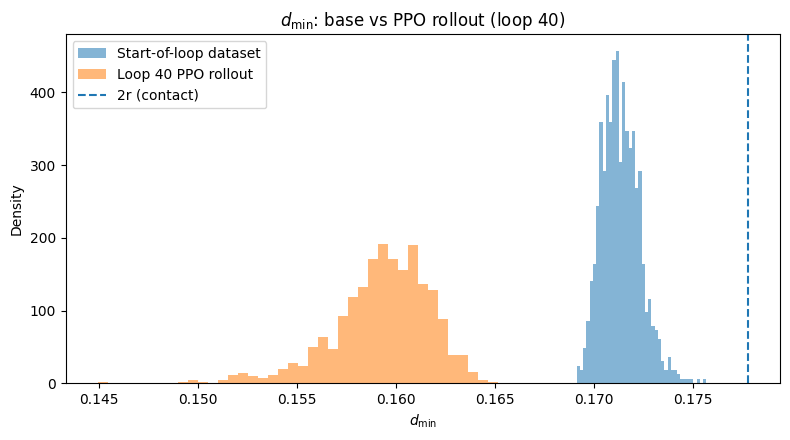

[base ] min=0.169139 med=0.171278 max=0.175706
[new  ] min=0.144967 med=0.159579 max=0.165177 | contact 2r = 0.177780


In [21]:
import os, glob, torch, numpy as np
import matplotlib.pyplot as plt

# ---------- user inputs ----------
RUN_DIR   = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/saved_models/run1_200/"
SAVE_G    = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/generated_sets/run1_200/"
DATA_PATH = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/200_srp.pt"
LOOP_ID   = 40        # choose which loop (e.g., 8 -> loop08_*.pth / loop08_*.npz)
NUM_SAMP  = 1000
BATCH     = 1000
USE_SAVED_SAMPLES = False

# Geometry you trained with
radius = 0.08888984075
clip_r = 1.0
pts    = 200
dim    = 3
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# ---------- tiny helpers ----------
def find_loop_ckpt(run_dir, loop_id):
    patt = os.path.join(run_dir, f"loop{loop_id:02d}_*.pth")
    files = sorted(glob.glob(patt))
    if not files: raise FileNotFoundError(f"No checkpoint for loop {loop_id} in {run_dir}")
    return files[-1]

def find_loop_npz(save_g, loop_id):
    patt = os.path.join(save_g, f"loop{loop_id:02d}_*.npz")
    files = sorted(glob.glob(patt))
    if not files: raise FileNotFoundError(f"No saved samples for loop {loop_id} in {save_g}")
    return files[-1]

def compute_min_dists(samples):  # samples: (S, d, N)
    if isinstance(samples, torch.Tensor): samples = samples.detach().cpu().numpy()
    S = samples.shape[0]; out = np.empty(S, dtype=np.float32)
    for i in range(S):
        x = torch.tensor(samples[i], dtype=torch.float32)   # (d,N)
        X = x.t()                                           # (N,d)
        D = torch.cdist(X, X, p=2.0)
        Nn = D.shape[0]
        D[torch.arange(Nn), torch.arange(Nn)] = float('inf')
        out[i] = D.min().item()
    return out

def load_base_samples(path):
    obj = torch.load(path, map_location="cpu")
    if isinstance(obj, torch.Tensor):
        arr = obj
    elif isinstance(obj, dict):
        for k in ["samples", "data", "centers", "x", "X"]:
            if k in obj and isinstance(obj[k], torch.Tensor):
                arr = obj[k]; break
        else:
            raise ValueError(f"Unrecognized structure in {path}. Keys: {list(obj.keys())}")
    else:
        raise ValueError(f"Unsupported file type: {type(obj)}")
    if arr.ndim != 3: raise ValueError(f"Expected 3D tensor, got {tuple(arr.shape)}")
    if arr.shape[1] == dim and arr.shape[2] == pts: return arr.numpy()
    if arr.shape[2] == dim and arr.shape[1] == pts: return arr.permute(0,2,1).numpy()
    raise ValueError(f"Unexpected shape {tuple(arr.shape)}")

# ---------- get "new" samples (either LOAD-SAVED or SAMPLE with PPO rollout) ----------
if USE_SAVED_SAMPLES:
    npz_path = find_loop_npz(SAVE_G, LOOP_ID)
    npz = np.load(npz_path)
    samples_new_np = npz["samples"]  # shape (K, d, N)
    # If you want exactly NUM_SAMP for plotting parity:
    if samples_new_np.shape[0] > NUM_SAMP:
        idx = np.random.RandomState(0).choice(samples_new_np.shape[0], size=NUM_SAMP, replace=False)
        samples_new_np = samples_new_np[idx]
else:
    # ---- sample from a loop checkpoint using PPO-guided rollout ----
    ckpt_path = find_loop_ckpt(RUN_DIR, LOOP_ID)
    ckpt = torch.load(ckpt_path, map_location=device)

    # --- model rebuild ---
    st_kwargs = (ckpt.get("params", {}).get("st_kwargs", None)) or \
                ckpt.get("config", {}).get("st_kwargs", None) or \
                {'dim_hidden':512,'num_heads':8,'cond_dim_in':4,'dim_out':dim}
    model = FlowSetTransformer(dim, **st_kwargs).to(device)
    sd = ckpt.get("model_state_dict") or ckpt.get("state_dict") or ckpt.get("model")
    if sd is None: raise RuntimeError("No model state dict in checkpoint.")
    model.load_state_dict(sd, strict=False)
    model.eval()

    # --- policy/value rebuild (if present) ---
    # Defaults match training setup
    LATENT_DIM = ckpt.get("config", {}).get("ppo_latent_dim", 32)
    STATE_DIM  = 14
    class TrajPolicy(nn.Module):
        def __init__(self, state_dim=STATE_DIM, latent_dim=LATENT_DIM, hidden=256):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(state_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
            )
            self.mu     = nn.Linear(hidden, latent_dim)
            self.logstd = nn.Linear(hidden, latent_dim)
        def forward(self, s):
            h = self.net(s)
            mu = self.mu(h)
            logstd = torch.clamp(self.logstd(h), -3.0, -1.0)
            return mu, logstd

    class TrajValue(nn.Module):
        def __init__(self, state_dim=STATE_DIM, hidden=256):
            super().__init__()
            self.v = nn.Sequential(
                nn.Linear(state_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, 1),
            )
        def forward(self, s):
            return self.v(s).squeeze(-1)

    traj_policy = TrajPolicy().to(device).eval()
    traj_value  = TrajValue().to(device).eval()
    if "policy_state_dict" in ckpt:
        try: traj_policy.load_state_dict(ckpt["policy_state_dict"], strict=False)
        except Exception as e: print(f"[warn] policy load_state_dict: {e}")
    if "value_state_dict" in ckpt:
        try: traj_value.load_state_dict(ckpt["value_state_dict"], strict=False)
        except Exception as e: print(f"[warn] value load_state_dict: {e}")

    # --- latent basis (same normalization as training) ---
    _FIELD_BASIS_CACHE = {}
    def get_latent_field_basis(latent_dim, d_local, N, device_):
        key = (latent_dim, d_local, N, str(device_))
        if key in _FIELD_BASIS_CACHE: return _FIELD_BASIS_CACHE[key]
        B = torch.randn(latent_dim, d_local, N, device=device_)
        B = B - B.mean(dim=-1, keepdim=True)
        rms = B.pow(2).mean(dim=(1,2), keepdim=True).sqrt().clamp_min(1e-8)
        B = B / rms
        _FIELD_BASIS_CACHE[key] = B
        return B
    latent_basis = get_latent_field_basis(LATENT_DIM, dim, pts, device)

    # --- rollout hparams (from checkpoint if available) ---
    rconf = ckpt.get("config", {}).get("traj_ppo_hparams", {})
    macro_K       = int(rconf.get("macro_K", 6))
    N_steps_total = int(rconf.get("N_steps_total", 100))
    sde_sigma0    = float(rconf.get("sde_sigma0", 0.000))
    sde_sigma1    = float(rconf.get("sde_sigma1", 0.0))
    latent_scale  = float(rconf.get("latent_scale", 0.4))  # may be absent; default matches training code
    control_decay = rconf.get("control_decay", "cosine")

    # --- condition vector (match training target) ---
    target_minsep_over_L = ckpt.get("config", {}).get("target_minsep_over_L", (2.0*radius)/clip_r)
    COND_VEC = np.array([radius/clip_r, pts/256.0, 0.6119413, target_minsep_over_L], dtype=np.float32)
    fixed_cond = torch.tensor(COND_VEC, device=device, dtype=torch.float32).unsqueeze(0).repeat(NUM_SAMP, 1)

    # --- rollout_trajectory sampler (import from training; assumed available) ---
    # Must be available in your codebase: rollout_trajectory, ODESolver, _sample_x1_box_faces_per_batch, _box_clamp
    samples_new_np_list = []
    left = NUM_SAMP
    with torch.no_grad():
        while left > 0:
            bs = min(BATCH, left)
            cond_chunk = fixed_cond[:bs]
            samples_chunk, _traj = rollout_trajectory(
                model=model,
                num_samples=bs, batch_size=bs, num_points=pts, device=device,
                sphere_radius=radius, clip_min=clip_r, clip_max=clip_r, dim=dim,
                fixed_cond=cond_chunk, latent_field_basis=latent_basis,
                latent_scale=latent_scale, macro_K=macro_K, N_steps_total=N_steps_total,
                control_decay=control_decay, sde_sigma0=sde_sigma0, sde_sigma1=sde_sigma1
            )
            samples_new_np_list.append(samples_chunk)
            left -= bs
    samples_new_np = np.concatenate(samples_new_np_list, axis=0)

# ---------- compute d_min ----------
dmin_new  = compute_min_dists(samples_new_np)
base      = load_base_samples(DATA_PATH)
if base.shape[0] > NUM_SAMP:
    idx = np.random.RandomState(0).choice(base.shape[0], size=NUM_SAMP, replace=False)
    base = base[idx]
dmin_base = compute_min_dists(base)

# ---------- plot comparison ----------
plt.figure(figsize=(8,4.5))
bins = 40
plt.hist(dmin_base, bins=bins, alpha=0.55, label="Start-of-loop dataset", density=True)
plt.hist(dmin_new,  bins=bins, alpha=0.55, label=("Saved elites" if USE_SAVED_SAMPLES else f"Loop {LOOP_ID} PPO rollout"), density=True)
plt.axvline(2*radius, ls='--', lw=1.5, label="2r (contact)")
plt.xlabel(r"$d_{\min}$"); plt.ylabel("Density")
plt.title(r"$d_{\min}$: base vs " + ("saved elites" if USE_SAVED_SAMPLES else f"PPO rollout (loop {LOOP_ID})"))
plt.legend(); plt.tight_layout(); plt.show()

# quick stats
def stats(x): 
    return f"min={x.min():.6f} med={np.median(x):.6f} max={x.max():.6f}"
print("[base ]", stats(dmin_base))
print("[new  ]", stats(dmin_new), "| contact 2r =", f"{2*radius:.6f}")

In [16]:
new  ] min=0.146992 med=0.159727 max=0.165343 | contact 2r = 0.177780

(2000, 3, 200)

In [15]:
os.makedirs(save_g, exist_ok=True)
out_path = os.path.join(save_g, "flowR1_200.pt")
torch.save(torch.from_numpy(samples_new_np), out_path)

batch 0: x(256, 3, 89) cond(256, 4) mask(256, 89) | d=3, Nmax=89
batch 1: x(256, 3, 89) cond(256, 4) mask(256, 89) | d=3, Nmax=89
batch 2: x(256, 3, 89) cond(256, 4) mask(256, 89) | d=3, Nmax=89
Collected cond shape: (405960, 4)


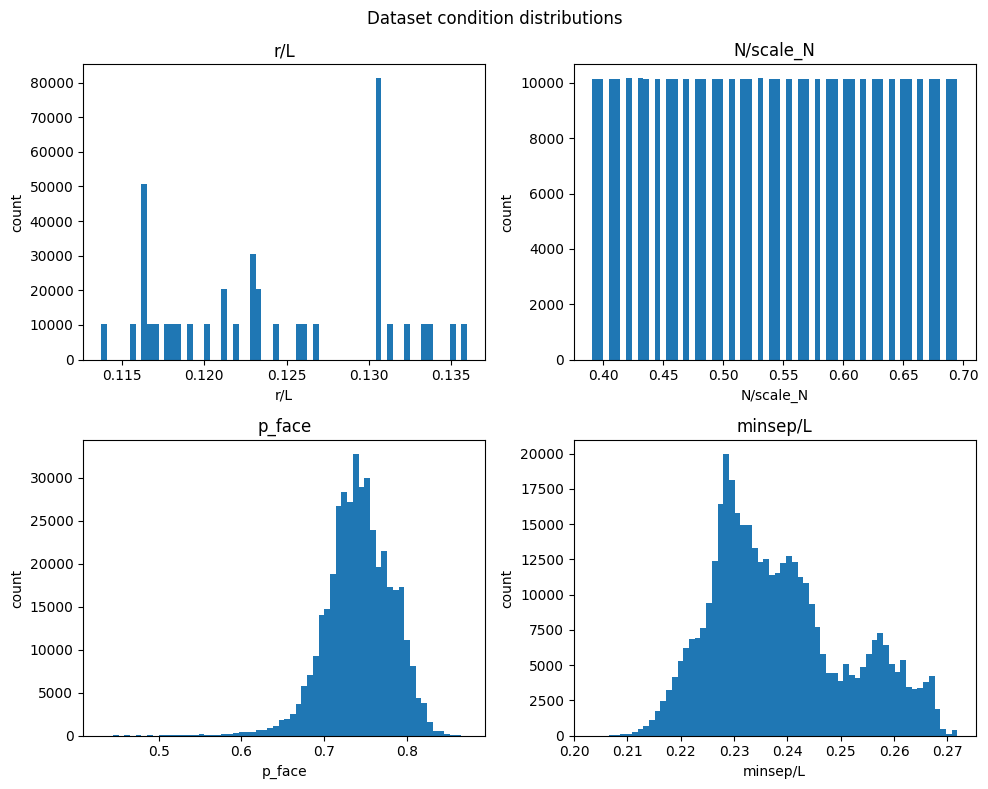

In [49]:
import torch
import matplotlib.pyplot as plt

for bi, (x, cond, mask) in enumerate(train_loader):
    # x: (B, d, Nmax)  cond: (B, 4)  mask: (B, Nmax) with True=attend
    print(f"batch {bi}: x{tuple(x.shape)} cond{tuple(cond.shape)} mask{tuple(mask.shape)} "
          f"| d={x.shape[1]}, Nmax={x.shape[2]}")
    if bi == 2:
        break

def collect_conditions(loader, max_batches=None):
    out = []
    for bi, (_, cond, _) in enumerate(loader):
        out.append(cond.cpu())
        if max_batches is not None and (bi + 1) >= max_batches:
            break
    return torch.cat(out, dim=0) if out else torch.empty(0, 4)

C = collect_conditions(train_loader, max_batches=None)  # shape: (num_samples, 4)
print("Collected cond shape:", tuple(C.shape))

names = ['r/L', 'N/scale_N', 'p_face', 'minsep/L']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i in range(4):
    # histogram per channel
    axes[i].hist(C[:, i].numpy(), bins=64)
    axes[i].set_title(names[i])
    axes[i].set_xlabel(names[i])
    axes[i].set_ylabel('count')
fig.suptitle('Dataset condition distributions', y=0.98)
plt.tight_layout()
plt.show()


In [50]:
for bi, (x, cond, mask) in enumerate(train_loader):
    N_eff = mask.sum(dim=1)           # (B,)
    print(f"batch {bi}: N_eff min={int(N_eff.min())}, max={int(N_eff.max())}, mean={float(N_eff.float().mean()):.2f}")
    if bi == 2:
        break


batch 0: N_eff min=50, max=89, mean=68.89
batch 1: N_eff min=50, max=89, mean=68.91
batch 2: N_eff min=50, max=89, mean=70.38


# Test

In [23]:
sec = cfg['flow_matching']
d = int(sec['dimension'])
bs = int(sec['batch_size'])
path = sec['dataset_path']
lr = float(sec['learning_rate'])
epochs = int(sec['num_epochs'])
radius = float(0.1306) 
mse_s  = float(sec['mse_strength'])
pen_s  = float(sec['distance_penality_strength'])
clip_r = float(sec['clip_sample_range'])
save_m = sec['save_model_path']
num_new= int(sec.get('sample_new_points', 2500))
batch_n= int(sec.get('sample_new_points_batch_size', 100))
pts = int(sec['num_spheres'])
save_g = sec['save_generated_path']
mixed_cond_path = sec.get('mixed_cond_path', None)  # e.g. "mixed_sphere_cond.pt"

In [24]:
mixed_cond_path, path

('diffuse_boost/output/new_sim/mixed_sphere_cond.pt',
 'diffuse_boost/output/new_sim/mixed_sphere.pt')

In [12]:
path = "/scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/srp_final_pushed_61.pt"
fixed_ds = SpherePackingDataset(
    path,
    radius=radius,
    box_len=clip_r,
    mixed_cond_path=None,
    num_sph=61
)

fixed_loader = DataLoader(fixed_ds,  batch_size=4200, num_workers=4, shuffle=False,
                          collate_fn=variable_length_collate, pin_memory=True)

Loaded cond cache: /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/srp_final_pushed_61.pt.cond.pt
Loaded /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/output/new_sim/srp_final_pushed_61.pt, shape (4200, 3, 61) | precomputed conds: (4200, 4)


In [26]:
iterator = iter(fixed_loader)
data_batch = next(iterator)
data_batch[0].shape

torch.Size([100, 3, 61])

In [77]:
os.makedirs(save_g, exist_ok=True)
out_path = os.path.join(save_g, "real_60}.pt")
torch.save(data_batch[0], out_path)

In [21]:
samples, masks = sample_flow_model(
    model, opt, 4200, 100, 61,
    dev, radius, clip_r, clip_r, d,
    cond_loader=fixed_loader, return_masks = True
)

In [40]:
save_g

'diffuse_boost/output/generated_sets/'

In [22]:
os.makedirs(save_g, exist_ok=True)
out_path = os.path.join(save_g, "flowR2_61.pt")
torch.save(torch.from_numpy(samples), out_path)

# Model Loading for Inference

In [18]:
#ckpt_path = "diffuse_boost/output/saved_models/flow_model_loss=0.0756_20250817_064432.pth"
ckpt_path = "diffuse_boost/output/saved_models/flow_model_loss=0.0731_20250822_210828.pth"
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
if isinstance(sd, dict) and len(sd) and next(iter(sd)).startswith("module."):
    sd = {k[7:]: v for k,v in sd.items()}

p = ckpt.get("params", {})
# map aliases / fallbacks
if "num_isab" in p and "depth" not in p: p["depth"] = int(p["num_isab"])
d = int(p.get("dim_out", cfg["flow_matching"]["dimension"]))
st_kwargs = {
    "dim_hidden":   int(p.get("dim_hidden",   cfg["flow_matching"].get("st_dim_hidden", 512))),
    "num_heads":    int(p.get("num_heads",    cfg["flow_matching"].get("st_num_heads", 8))),
    "depth":        int(p.get("depth", 2)),
    "cond_dim_in":  int(p.get("cond_dim_in", 4)),
}
# optional keys if they were used during training
for k in ["ff_mult","attn_dropout","ff_dropout","dim_time","time_fourier_dim","time_hidden","time_fourier_sigma","cond_hidden"]:
    if k in p: st_kwargs[k] = type(p[k])(p[k])

model = FlowSetTransformer(d, **st_kwargs).to(device)
model.load_state_dict(sd, strict=True)
model.eval()

FlowSetTransformer(
  (time_emb): TimeEmbedFourier(
    (net): Sequential(
      (0): Linear(in_features=68, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (cond_mlp): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (token_in): Linear(in_features=131, out_features=512, bias=True)
  (timecond_to_film): Sequential(
    (0): SiLU()
    (1): Linear(in_features=128, out_features=1024, bias=True)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0): ModuleList(
        (0): ModuleList(
          (0): RMSNorm()
          (1-2): 2 x None
        )
        (1): Attention(
          (to_q): Linear(in_features=512, out_features=512, bias=False)
          (to_k): Linear(in_features=512, out_features=512, bias=False)
          (to_v): Linear(in_features=512, out_features=512, bias=False)
          (split_q_heads)

# Metric Evaluation

### Sampling with ODESolver with PCFM --> (Best Version!)

In [19]:
@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, 
                      cond_loader=None, de_novo = False, return_masks = False):

    # Hyperparameters
    N_steps = 100
    ode_method = 'midpoint'
    ode_step_cap = 0.1
    jitter = 5e-3
    eps_nrm = 1e-6
    proj_outer_iters = 8
    alpha_proj = 0.25
    contact_q = 1.0
    wall_weight = 1.0
    wall_margin = 0.05
    prox_iters = 10
    prox_step = 0.2
    prox_lambda = 2.0
    final_passes = 20
    tol_finish = 1e-8

    L = torch.tensor(float(clip_max), device=device)
    r_default = torch.tensor(float(sphere_radius), device=device)

    def _clamp_box_local(x, r_b):
        return _box_clamp(x, r_b, L)

    class _FMVF:
        def __init__(self, mdl, cond, mask):
            self.mdl, self.cond, self.mask = mdl, cond, mask
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond, mask=self.mask) if self.cond is not None else self.mdl(tb, x, mask=self.mask)

    def _ode_solve_with_model(x_init, tau_start, tau_end, cond, mask, r_b):
        t0, t1 = 1.0 - float(tau_start), 1.0 - float(tau_end)
        solver = ODESolver(velocity_model=_FMVF(model, cond, mask))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box_local(x_end, r_b)

    def _active_overlap(u, r_b, mask, for_stop=False):
        """
        Returns overlap>=0 on active pairs only; masked pairs set to 0.
        """
        B, d, N = u.shape
        P = u.permute(0, 2, 1).contiguous()         # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r_b.view(-1, 1, 1)) * torch.randn_like(P)

        diff = P[:, :, None, :] - P[:, None, :, :]  # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)   # (B,N,N)
        n    = diff / dist.unsqueeze(-1)            # (B,N,N,d)

        overlap = (2.0 * r_b.view(-1,1,1) - dist)   # (B,N,N)
        eye = torch.eye(N, device=u.device, dtype=torch.bool)[None]
        pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
        overlap = torch.where(pairmask, overlap, torch.zeros_like(overlap))
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0:
            return pos
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(flat.size(0), -1), 1.0 - q, dim=1, keepdim=True)
        return pos & (overlap >= thr.view(-1, 1, 1))

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float())                    # (B,N,N)
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)               # (B,N,d)
        term_j = (w.transpose(1, 2).unsqueeze(-1)
                  * n.transpose(1, 2)).sum(dim=2)               # (B,N,d)
        delta = term_i - term_j                                 # (B,N,d)
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)                  # (B,d,N)
        return delta

    def _wall_push(u, r_b, mask, margin_frac=0.05, scale=1.0):
        B, d, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r_b).view(-1, 1, 1)
        for ax in range(d):
            dl = u[:, ax, :] - r_b.view(-1, 1)                  # dist to low face
            dh = (L - r_b).view(-1, 1) - u[:, ax, :]            # dist to high face
            near_low  = (dl < thr.view(-1,1))
            near_high = (dh < thr.view(-1,1))
            delta[:, ax, :] += torch.where(near_low,  (thr.view(-1,1) - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr.view(-1,1) - dh), 0.0)
        # zero out on padded tokens
        delta = delta * mask[:, None, :].to(delta.dtype)
        return scale * delta

    def _project_terminal(u, r_b, mask):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, r_b, mask, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0:
                break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, r_b, mask, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box_local(u + alpha_proj * (delta_pairs + delta_walls), r_b)
        return u

    def _Jt_h_at_state(u_next, r_b, mask):
        overlap, n, eye = _active_overlap(u_next, r_b, mask, for_stop=False)
        active = (overlap > 0) & (~eye)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))                       # (B,N,d)
        term_j = (+(w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0, 2, 1)                      # (B,d,N)
        jt_walls = _wall_push(u_next, r_b, mask, margin_frac=wall_margin, scale=1.0)
        return jt_pairs + wall_weight * jt_walls

    def _prox_relaxed(u, u0, u_proj, tau_prime, cond, r_b, mask):
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v = model(tb, u, cond=cond, mask=mask) if cond is not None else model(tb, u, mask=mask)
            u_next = _clamp_box_local(u + (1.0 - tau_prime) * v, r_b)
            jt_h = _Jt_h_at_state(u_next, r_b, mask)
            grad = (u - u_hat) + prox_lambda * jt_h
            u = _clamp_box_local(u - prox_step * grad, r_b)
        return u

    #def _final_polish(u, r_b, mask):
    #    for _ in range(final_passes):
    #        overlap, _, _ = _active_overlap(u, r_b, mask, for_stop=True)
    #        if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
    #            break
    #        u = _project_terminal(u, r_b, mask)
    #    return u

    def _final_polish(u, r_b, mask):
        saved_wall_w = wall_weight
        saved_margin = wall_margin
        try:
            # disable wall during final tightening
            locals()['wall_weight'] = 0.0
            locals()['wall_margin'] = 0.0
            for _ in range(final_passes):
                overlap, _, _ = _active_overlap(u, r_b, mask, for_stop=True)
                if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
                    break
                u = _project_terminal(u, r_b, mask)
        finally:
            locals()['wall_weight'] = saved_wall_w
            locals()['wall_margin'] = saved_margin
        return u

    model.eval()
    optimizer.eval()

    samples, masks_out, remaining = [], [], int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None

    while remaining > 0:
        bs = min(batch_size, remaining)
        if cond_iter is not None:
            try:
                x_dummy, cond, mask = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                x_dummy, cond, mask = next(cond_iter)
            cond = cond.to(device)
            mask = mask.to(device)                  # (B, Ncond_max)
            if cond.size(0) > bs:
                cond = cond[:bs]
                mask = mask[:bs]
            #extrapolative de novo design
            if de_novo:
                cond = cond.clone()
                cond[:, 3] = cond[:, 3] + 0.1
            

            # per-sample radius
            r_batch = (cond[:, 0] * L).to(torch.float32)        # (B,)

            # we keep fixed output width N=num_points; adapt mask to that width
            if mask.size(1) < num_points:
                pad = torch.zeros(mask.size(0), num_points - mask.size(1), dtype=mask.dtype, device=device)
                mask = torch.cat([mask, pad], dim=1)
            elif mask.size(1) > num_points:
                mask = mask[:, :num_points]
        else:
            cond = None
            r_batch = r_default.repeat(bs)                      # (B,)
            mask = torch.ones(bs, num_points, dtype=torch.bool, device=device)

        # Initialize u0 at tau=0, clamp
        p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r_batch, L=L, p_face_batch=p_face_batch, jitter=jitter
        )
        u0 = _clamp_box_local(u0, r_batch)
        u = u0.clone()

        # tau grid evolution
        for k in range(N_steps):
            tau      = k / N_steps
            tau_next = (k + 1) / N_steps
            # forward shoot to tau=1
            u1 = _ode_solve_with_model(u, tau, 1.0, cond, mask, r_batch)
            # terminal projection
            u_proj = _project_terminal(u1, r_batch, mask)
            # relaxed reverse step
            u = _prox_relaxed(u, u0, u_proj, tau_next, cond, r_batch, mask)

        u = _final_polish(u, r_batch, mask)
        samples.append(u.cpu().numpy())
        if return_masks:
            masks_out.append(mask.cpu().numpy())
        remaining -= bs

    samples_np = np.concatenate(samples, axis=0)          # (num_samples, d, num_points)
    if return_masks:
        masks_np = np.concatenate(masks_out, axis=0)      # (num_samples, num_points)
        return samples_np, masks_np
    return samples_np


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=10200 mean=0.020871  std=0.005205  min=0.000000  max=0.036688
  Generated-> n=10200 mean=0.034719  std=0.005566  min=0.021060  max=0.060159
[min_nearest_neighbor_dist]
  Test     -> n=10200 mean=0.240333  std=0.005205  min=0.224516  max=0.261204
  Generated-> n=10200 mean=0.226485  std=0.005566  min=0.201045  max=0.240144


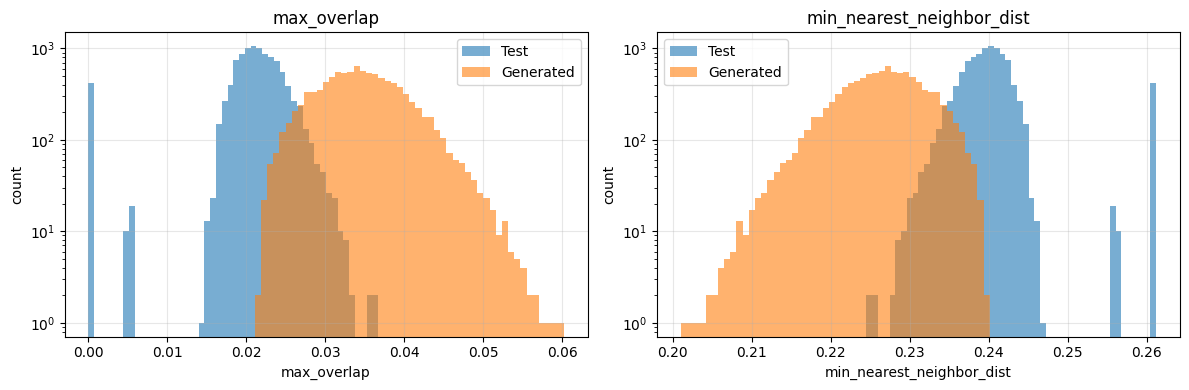

In [32]:
gen_points = pts
base_ds = getattr(fixed_loader.dataset, 'dataset', None)
if base_ds is not None and getattr(base_ds, 'mixed_mode', False):
    gen_points = max(g["N"] for g in base_ds.groups)

results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=fixed_loader,   #(x, cond, mask), per-sample r used internally
    device=dev,
    radius=radius,          
    clip_range=clip_r,
    d=d,
    num_points=gen_points,
    num_eval_events=10200,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=4200  mean=0.011905  std=0.008351  min=0.000000  max=0.021621
  Generated-> n=4200  mean=0.027417  std=0.004815  min=0.020789  max=0.056637
[min_nearest_neighbor_dist]
  Test     -> n=4200  mean=0.249295  std=0.008352  min=0.239579  max=0.261203
  Generated-> n=4200  mean=0.233783  std=0.004815  min=0.204563  max=0.240411


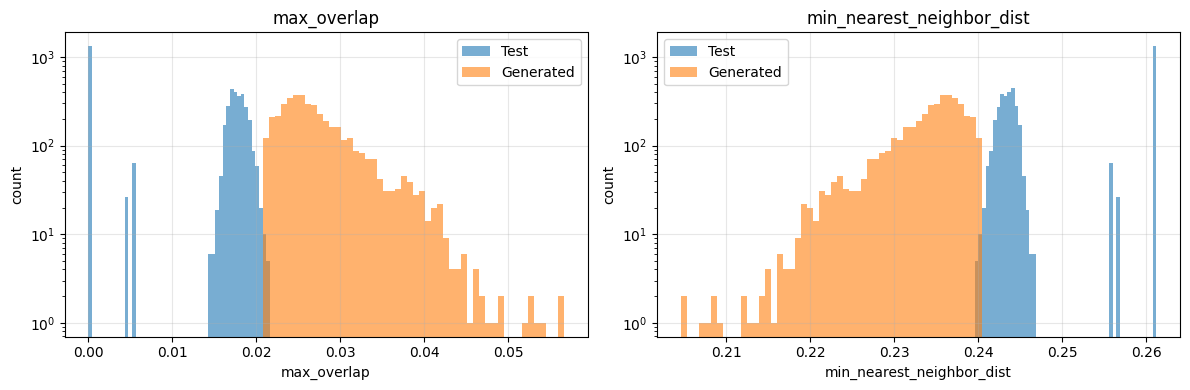

In [20]:
gen_points = pts
base_ds = getattr(fixed_loader.dataset, 'dataset', None)
if base_ds is not None and getattr(base_ds, 'mixed_mode', False):
    gen_points = max(g["N"] for g in base_ds.groups)

results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=fixed_loader,   #(x, cond, mask), per-sample r used internally
    device=dev,
    radius=radius,          
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=4200,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=4200  mean=0.011905  std=0.008351  min=0.000000  max=0.021621
  Generated-> n=4200  mean=0.029506  std=0.005530  min=0.020976  max=0.059750
[min_nearest_neighbor_dist]
  Test     -> n=4200  mean=0.249295  std=0.008352  min=0.239579  max=0.261203
  Generated-> n=4200  mean=0.231694  std=0.005530  min=0.201450  max=0.240224


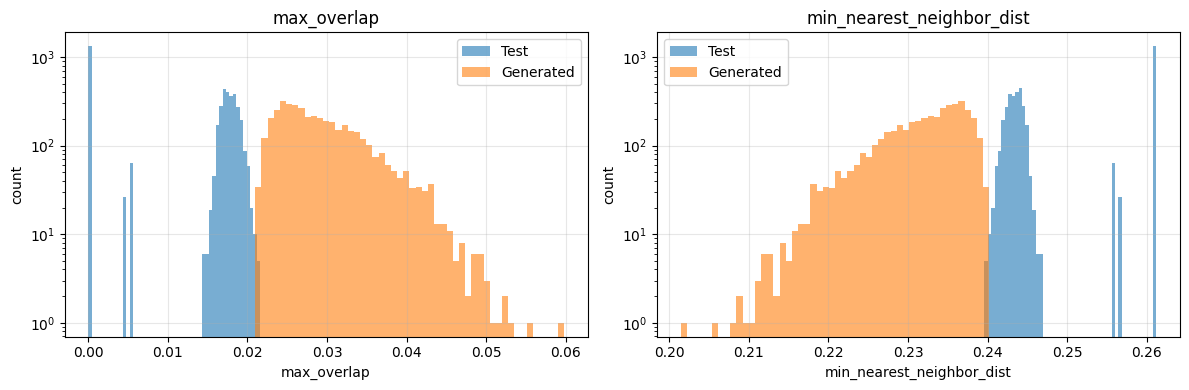

In [15]:
gen_points = pts
base_ds = getattr(fixed_loader.dataset, 'dataset', None)
if base_ds is not None and getattr(base_ds, 'mixed_mode', False):
    gen_points = max(g["N"] for g in base_ds.groups)

results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=fixed_loader,   #(x, cond, mask), per-sample r used internally
    device=dev,
    radius=radius,          
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=4200,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=1000  mean=0.003656  std=0.001904  min=0.000066  max=0.009990
  Generated-> n=1000  mean=0.023812  std=0.004809  min=0.015070  max=0.046354
[min_nearest_neighbor_dist]
  Test     -> n=1000  mean=0.223884  std=0.001904  min=0.217549  max=0.227474
  Generated-> n=1000  mean=0.203728  std=0.004809  min=0.181185  max=0.212469


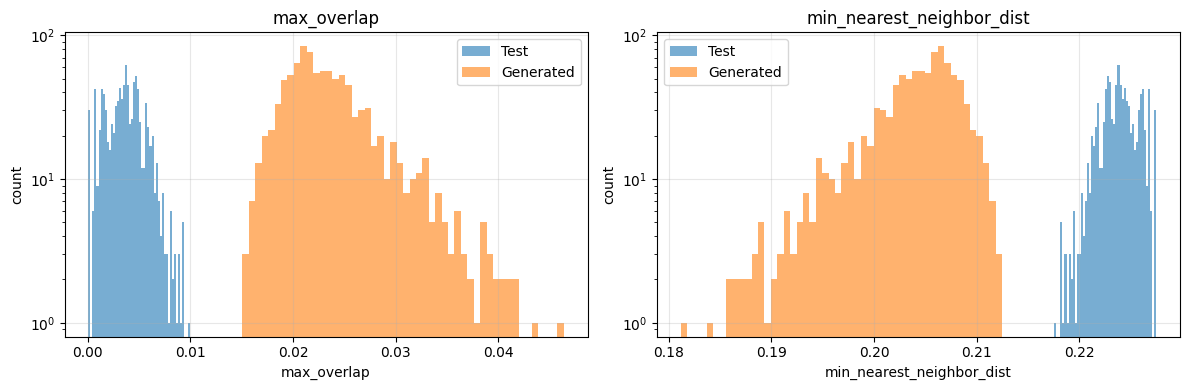

In [68]:
#Sampling with PCFM v2 (BEST)
results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,
    device=dev,
    radius=radius,
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=1000,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)